In [1051]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 1. Environment Setup & Data Loading

In [1052]:
df = pd.read_csv(filepath_or_buffer="All_State_NCRB_Crime_Data_2014.csv")
df.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
0,Andhra Pradesh,Anantapur,2014,134,171,8,0,35,0,0,...,0,0,0,0,0,1038,0,0,3800,8376
1,Andhra Pradesh,Chittoor,2014,84,170,2,0,32,0,0,...,0,0,0,19,0,249,0,0,2567,5374
2,Andhra Pradesh,Cuddapah,2014,80,162,1,0,28,0,0,...,0,0,0,0,0,948,0,0,2604,5803
3,Andhra Pradesh,East Godavari,2014,64,84,2,0,85,0,0,...,0,0,0,32,0,39,0,0,3791,7630
4,Andhra Pradesh,Guntakal Railway,2014,14,4,0,0,0,0,0,...,0,0,0,0,0,1,0,0,37,490


In [1053]:
NUMERICAL_COLS = df.select_dtypes(include=np.number).columns
CATEGORICAL_COLS = df.select_dtypes(include="str").columns

In [1054]:
len((df["States/UTs"]).value_counts())

36

### 2. Separation of Aggregates vs. District Granularity

In [1055]:
df.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
0,Andhra Pradesh,Anantapur,2014,134,171,8,0,35,0,0,...,0,0,0,0,0,1038,0,0,3800,8376
1,Andhra Pradesh,Chittoor,2014,84,170,2,0,32,0,0,...,0,0,0,19,0,249,0,0,2567,5374
2,Andhra Pradesh,Cuddapah,2014,80,162,1,0,28,0,0,...,0,0,0,0,0,948,0,0,2604,5803
3,Andhra Pradesh,East Godavari,2014,64,84,2,0,85,0,0,...,0,0,0,32,0,39,0,0,3791,7630
4,Andhra Pradesh,Guntakal Railway,2014,14,4,0,0,0,0,0,...,0,0,0,0,0,1,0,0,37,490


In [1056]:
df_district = df[df["District"] != "Total"]
df_state_totals = df[df["District"] == "Total"]

if (
    df_district["Total Cognizable IPC crimes"].sum()
    == df_state_totals["Total Cognizable IPC crimes"].sum()
):
    print("No double-counting included")
else:
    print("There is some double-counting")


No double-counting included


### 3. Identifying Special Administrative Units (Railway & Crime Branch Districts)

In [1057]:
non_standard_places = ["Railway", "Crime Branch", "CID"]

pattern = "|".join(non_standard_places)

non_standard_districts = df[
    df["District"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True,
    )
]

non_standard_districts.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
4,Andhra Pradesh,Guntakal Railway,2014,14,4,0,0,0,0,0,...,0,0,0,0,0,1,0,0,37,490
15,Andhra Pradesh,Vijayawada Railway,2014,1,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,59,1223
23,Arunachal Pradesh,Crime Branch,2014,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
84,Bihar,Jamalpur Railway,2014,9,1,0,0,0,0,0,...,0,0,0,2,0,0,0,0,72,298
88,Bihar,Katihar Railway,2014,10,9,0,0,0,0,0,...,0,0,0,0,0,0,3,0,61,313


In [1058]:
avg_murder_df = (
    non_standard_districts.groupby(["States/UTs", "District"])
    .agg(
        avg_murder=("Murder", "mean"),
    )
    .reset_index()
)

avg_murder_df.head()

,States/UTs,District,avg_murder
0,Andhra Pradesh,Guntakal Railway,14.0
1,Andhra Pradesh,Vijayawada Railway,1.0
2,Arunachal Pradesh,Crime Branch,0.0
3,Bihar,Jamalpur Railway,9.0
4,Bihar,Katihar Railway,10.0


In [1059]:
avg_murder_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   States/UTs  27 non-null     str    
 1   District    27 non-null     str    
 2   avg_murder  27 non-null     float64
dtypes: float64(1), str(2)
memory usage: 780.0 bytes


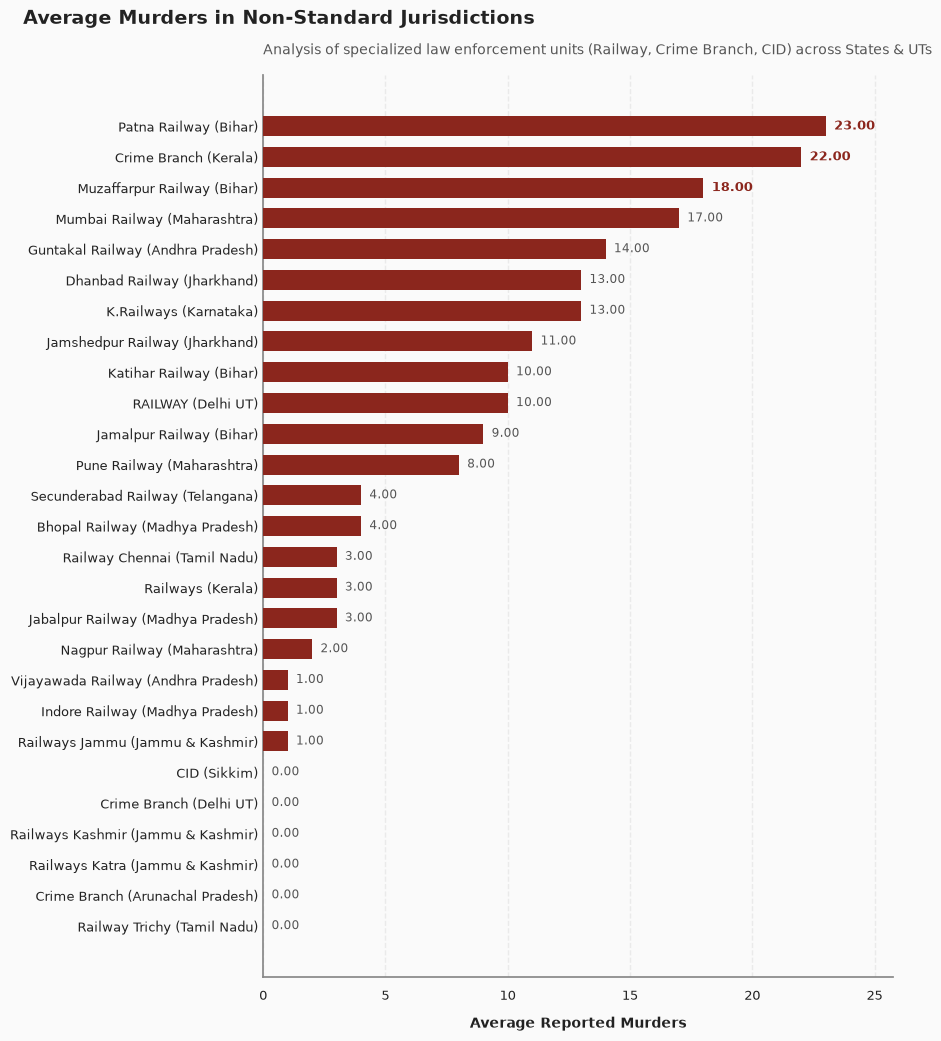

In [1060]:
df_plot = avg_murder_df.reset_index()
df_plot["Location"] = df_plot["District"] + " (" + df_plot["States/UTs"] + ")"
df_plot = df_plot.sort_values(by="avg_murder", ascending=True)

color_main = "#8B261D"
color_subtle = "#E2938C"
color_bg = "#FAFAFA"
color_text = "#222222"
color_grid = "#E0E0E0"

fig, ax = plt.subplots(figsize=(10, 11), facecolor=color_bg)
ax.set_facecolor(color_bg)

y_positions = range(len(df_plot))
bars = ax.barh(
    y_positions,
    df_plot["avg_murder"],
    height=0.65,
    color=color_main,
    edgecolor="none",
    zorder=3,
)

max_val = df_plot["avg_murder"].max()
top_3_indices = set(df_plot.tail(3).index)

for i, (idx, row) in enumerate(df_plot.iterrows()):
    val = row["avg_murder"]
    if idx in top_3_indices:
        ax.text(
            val + (max_val * 0.015),
            i,
            f"{val:.2f}",
            va="center",
            ha="left",
            fontsize=9.5,
            fontweight="bold",
            color=color_main,
            zorder=4,
        )
    else:
        ax.text(
            val + (max_val * 0.015),
            i,
            f"{val:.2f}",
            va="center",
            ha="left",
            fontsize=8.5,
            color="#555555",
            zorder=4,
        )

ax.set_yticks(y_positions)
ax.set_yticklabels(df_plot["Location"], fontsize=9, color=color_text)

ax.xaxis.grid(True, linestyle="--", alpha=0.6, color=color_grid, zorder=1)
ax.yaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("#888888")
ax.spines["left"].set_color("#888888")

ax.tick_params(axis="x", colors=color_text, labelsize=9)
ax.tick_params(axis="y", colors=color_text, length=0)

ax.set_xlim(0, max_val * 1.12)
ax.set_xlabel(
    "Average Reported Murders",
    fontsize=10,
    fontweight="bold",
    color=color_text,
    labelpad=10,
)

fig.suptitle(
    "Average Murders in Non-Standard Jurisdictions",
    fontsize=14,
    fontweight="bold",
    color=color_text,
    x=0.08,
    y=0.96,
    ha="left",
)
ax.set_title(
    "Analysis of specialized law enforcement units (Railway, Crime Branch, CID) across States & UTs",
    fontsize=10,
    color="#555555",
    pad=15,
    loc="left",
)

plt.subplots_adjust(top=0.90, bottom=0.08, left=0.32, right=0.95)
plt.show()

### 4. State-Wise Ranking of Cognizable Crimes

In [1061]:
state_wise_crimes = (
    df_state_totals.groupby("States/UTs")
    .agg(
        total_crime=("Total Cognizable IPC crimes", "sum"),
    )
    .reset_index()
)

TOTAL_CRIME_ACROSS_STATES = state_wise_crimes["total_crime"].sum()

state_wise_crimes["distribution_perc"] = np.round(
    (state_wise_crimes["total_crime"] / TOTAL_CRIME_ACROSS_STATES) * 100, 2
)

state_wise_crimes = state_wise_crimes.sort_values(
    by="distribution_perc", ascending=False
).reset_index()

top5 = state_wise_crimes.head(5)
bottom5 = state_wise_crimes.tail(5)

In [1062]:
state_wise_crimes.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              36 non-null     int64  
 1   States/UTs         36 non-null     str    
 2   total_crime        36 non-null     int64  
 3   distribution_perc  36 non-null     float64
dtypes: float64(1), int64(2), str(1)
memory usage: 1.3 KB


In [1063]:
top5

,index,States/UTs,total_crime,distribution_perc
0,19,Madhya Pradesh,272423,9.53
1,20,Maharashtra,249834,8.74
2,33,Uttar Pradesh,240475,8.41
3,28,Rajasthan,210418,7.36
4,17,Kerala,206789,7.23


In [1064]:
bottom5

,index,States/UTs,total_crime,distribution_perc
31,29,Sikkim,1065,0.04
32,0,A&N Islands,746,0.03
33,8,Daman & Diu,233,0.01
34,7,D&N Haveli,277,0.01
35,18,Lakshadweep,81,0.00


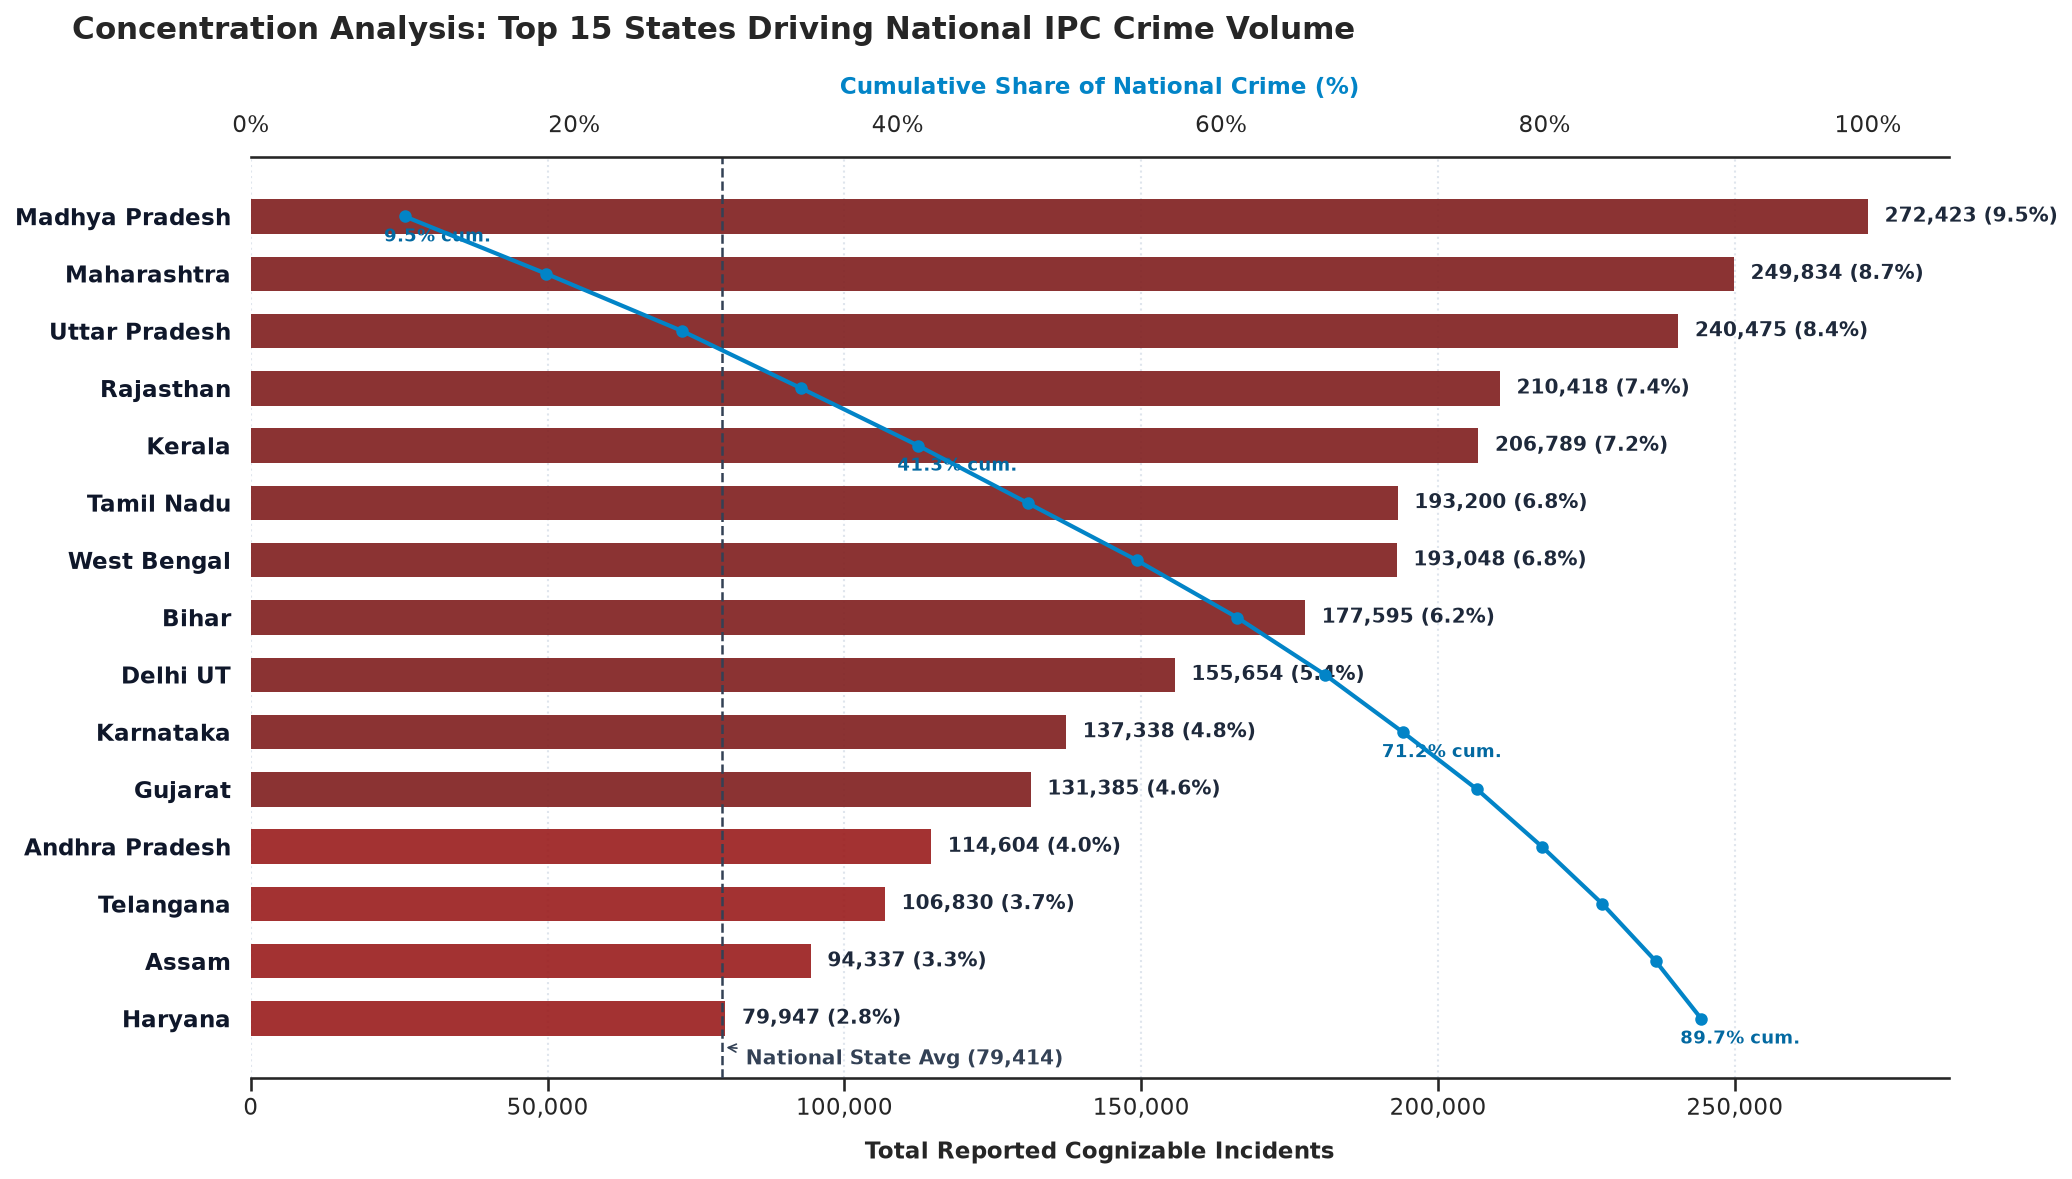

In [1065]:
df = state_wise_crimes.copy(deep=True)

df["total_crime"] = pd.to_numeric(df["total_crime"], errors="coerce").fillna(0)
df["distribution_perc"] = pd.to_numeric(
    df["distribution_perc"], errors="coerce"
).fillna(0)

top_15 = (
    df.sort_values(by="total_crime", ascending=False).head(15).reset_index(drop=True)
)

mean_crime = df["total_crime"].mean()
top_15["cum_perc"] = top_15["distribution_perc"].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 8), dpi=150)

y_positions = np.arange(len(top_15))
bar_colors = [
    "#7f1d1d" if x > mean_crime * 1.5 else "#991b1b" if x > mean_crime else "#475569"
    for x in top_15["total_crime"]
]

bars = ax1.barh(
    y_positions,
    top_15["total_crime"],
    align="center",
    color=bar_colors,
    height=0.6,
    edgecolor="none",
    alpha=0.9,
)

ax1.axvline(
    mean_crime,
    color="#334155",
    linestyle="--",
    linewidth=1.2,
    zorder=3,
)

ax1.set_yticks(y_positions)
ax1.set_yticklabels(
    top_15["States/UTs"],
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
)
ax1.invert_yaxis()

ax1.set_xlabel(
    "Total Reported Cognizable Incidents",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
)
ax1.xaxis.set_major_formatter("{x:,.0f}")
ax1.xaxis.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")
ax1.set_axisbelow(True)

for idx, row in top_15.iterrows():
    ax1.annotate(
        f"{int(row['total_crime']):,} ({row['distribution_perc']:.1f}%)",
        (row["total_crime"], idx),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="bold",
        color="#1e293b",
    )

ax1.annotate(
    f"National State Avg ({int(mean_crime):,})",
    xy=(mean_crime, len(top_15) - 0.5),
    xytext=(mean_crime * 1.05, len(top_15) - 0.2),
    fontsize=9.5,
    fontweight="bold",
    color="#334155",
    arrowprops={
        "arrowstyle": "->",
        "color": "#334155",
        "lw": 0.8,
    },
)

ax2 = ax1.twiny()
ax2.plot(
    top_15["cum_perc"],
    y_positions,
    color="#0284c7",
    linewidth=2,
    marker="o",
    markersize=5,
    zorder=4,
)
ax2.set_xlabel(
    "Cumulative Share of National Crime (%)",
    fontsize=11,
    fontweight="bold",
    color="#0284c7",
    labelpad=10,
)
ax2.set_xlim(0, 105)
ax2.xaxis.set_major_formatter("{x:.0f}%")

for idx, val in enumerate(top_15["cum_perc"]):
    if idx in [0, 4, 9, 14]:
        ax2.annotate(
            f"{val:.1f}% cum.",
            (val, idx),
            xytext=(-10, -12),
            textcoords="offset points",
            fontsize=8.5,
            fontweight="bold",
            color="#0369a1",
        )

sns.despine(ax=ax1, top=True, right=True, left=True, bottom=False)
sns.despine(ax=ax2, top=False, right=True, left=True, bottom=True)

plt.suptitle(
    "Concentration Analysis: Top 15 States Driving National IPC Crime Volume",
    fontsize=15,
    fontweight="bold",
    x=0.04,
    ha="left",
    y=0.98,
)

plt.tight_layout()
plt.show()

### 5. Analysis of Violent Crimes Against Person

In [1066]:
df_state_totals.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
20,Andhra Pradesh,Total,2014,1175,1540,52,1,961,0,0,...,21,21,0,276,0,14653,2,1,44187,114604
40,Arunachal Pradesh,Total,2014,86,48,4,0,83,4,0,...,0,0,0,121,0,102,0,0,720,2843
69,Assam,Total,2014,1451,1142,57,14,1980,0,0,...,0,0,0,1226,0,3202,68,0,29212,94337
116,Bihar,Total,2014,3403,4379,201,463,1127,0,0,...,0,0,0,972,0,3485,44,5,75799,177595
145,Chhattisgarh,Total,2014,998,716,29,0,1436,0,0,...,3,3,0,74,0,7759,43,22,21897,58200


In [1067]:
violent_crimes = df_state_totals.copy(deep=True)

target_cols = [
    "Murder",
    "Attempt to commit Murder",
    "Culpable Homicide not amounting to Murder",
    "Attempt to commit Culpable Homicide",
]

violent_crimes["Violent_Crimes_Person"] = df_state_totals[target_cols].sum(axis=1)

violent_crimes = violent_crimes[["States/UTs", "Violent_Crimes_Person"]].reset_index()
violent_crimes.head(10)

,index,States/UTs,Violent_Crimes_Person
0,20,Andhra Pradesh,2768
1,40,Arunachal Pradesh,138
2,69,Assam,2664
3,116,Bihar,8446
4,145,Chhattisgarh,1743
5,149,Goa,82
6,191,Gujarat,1940
7,216,Haryana,1963
8,232,Himachal Pradesh,202
9,263,Jammu & Kashmir,660


In [1068]:
violent_crimes.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   index                  36 non-null     int64
 1   States/UTs             36 non-null     str  
 2   Violent_Crimes_Person  36 non-null     int64
dtypes: int64(2), str(1)
memory usage: 996.0 bytes


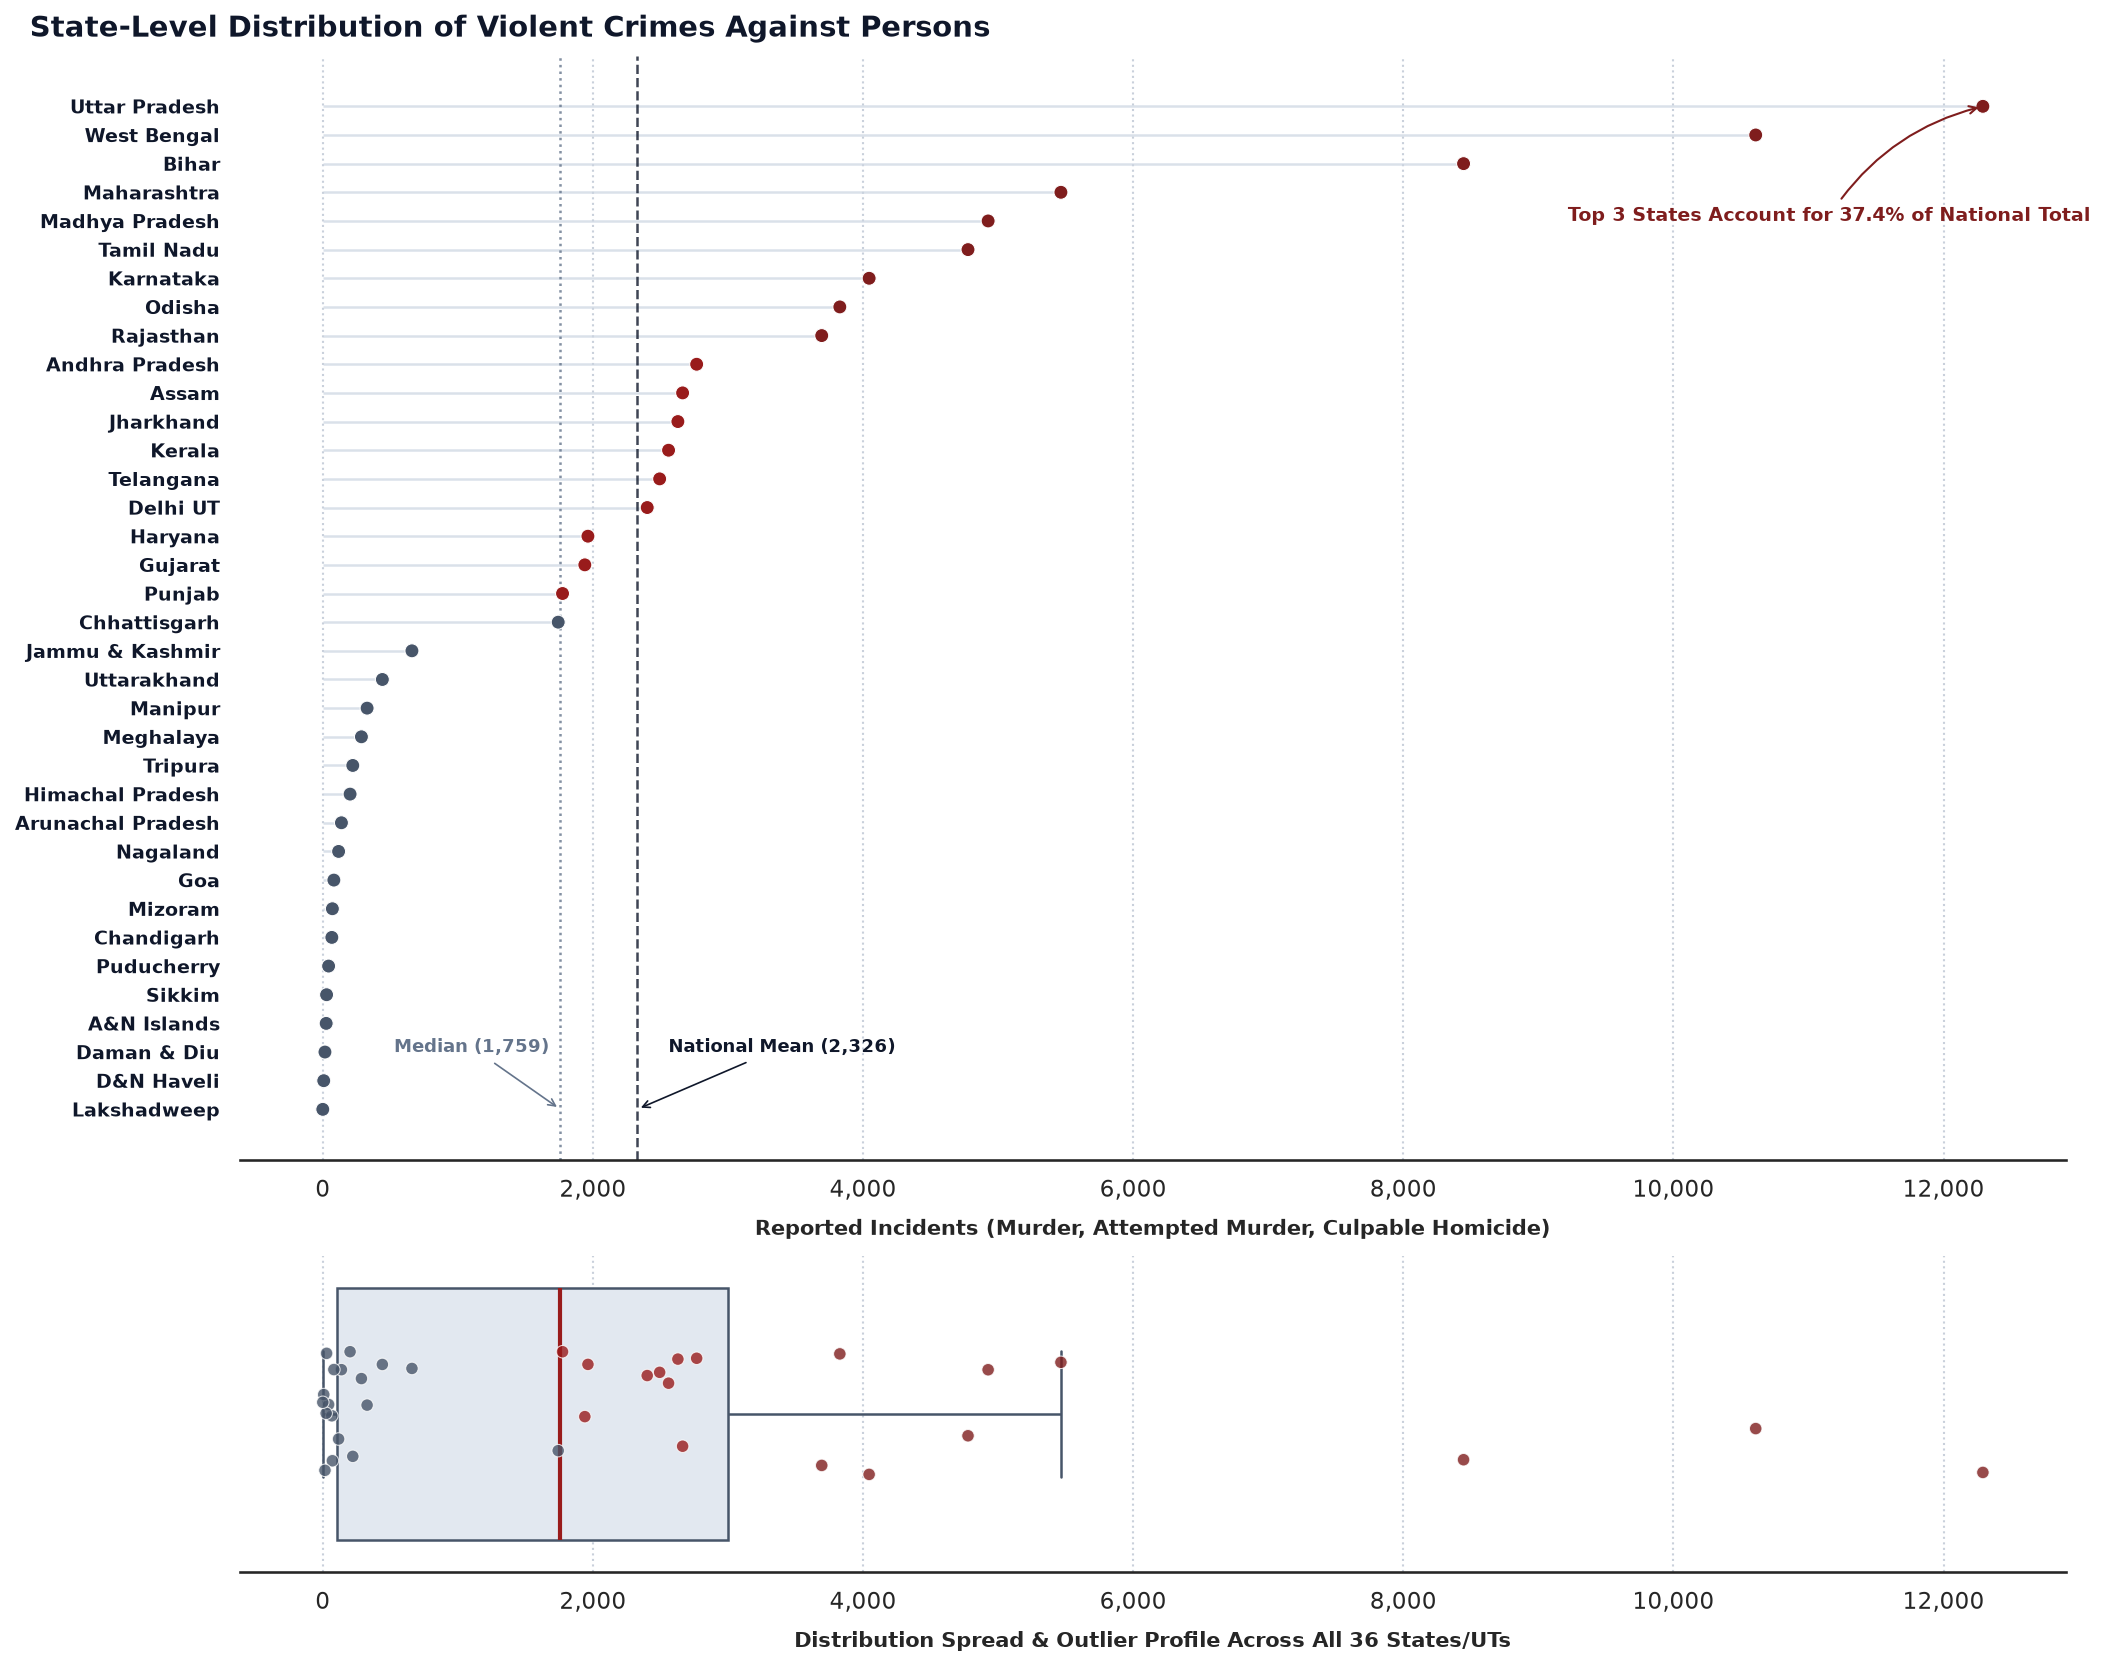

In [1069]:
df = violent_crimes.copy(deep=True)

df["Violent_Crimes_Person"] = pd.to_numeric(
    df["Violent_Crimes_Person"], errors="coerce"
).fillna(0)

df_sorted = df.sort_values(by="Violent_Crimes_Person", ascending=False).reset_index(
    drop=True
)

national_total = df_sorted["Violent_Crimes_Person"].sum()
df_sorted["share_perc"] = (df_sorted["Violent_Crimes_Person"] / national_total) * 100
df_sorted["cum_share"] = df_sorted["share_perc"].cumsum()

mean_val = df_sorted["Violent_Crimes_Person"].mean()
median_val = df_sorted["Violent_Crimes_Person"].median()
q3_val = df_sorted["Violent_Crimes_Person"].quantile(0.75)

fig, (ax_main, ax_dist) = plt.subplots(
    2,
    1,
    figsize=(14, 11),
    dpi=150,
    sharex=False,
    layout="constrained",
    gridspec_kw={"height_ratios": [3.5, 1]},
)

y_pos = np.arange(len(df_sorted))

dot_colors = [
    "#7f1d1d" if x >= q3_val else "#991b1b" if x >= median_val else "#475569"
    for x in df_sorted["Violent_Crimes_Person"]
]

ax_main.hlines(
    y=y_pos,
    xmin=0,
    xmax=df_sorted["Violent_Crimes_Person"],
    color="#cbd5e1",
    alpha=0.7,
    linewidth=1.2,
    zorder=1,
)

ax_main.scatter(
    df_sorted["Violent_Crimes_Person"],
    y_pos,
    c=dot_colors,
    s=45,
    zorder=3,
    edgecolor="white",
    linewidth=0.5,
)

ax_main.axvline(
    mean_val,
    color="#0f172a",
    linestyle="--",
    linewidth=1.2,
    zorder=2,
    alpha=0.8,
)

ax_main.axvline(
    median_val,
    color="#64748b",
    linestyle=":",
    linewidth=1.2,
    zorder=2,
    alpha=0.8,
)

ax_main.set_yticks(y_pos)
ax_main.set_yticklabels(
    df_sorted["States/UTs"], fontsize=9, fontweight="bold", color="#0f172a"
)
ax_main.invert_yaxis()

ax_main.set_xlabel(
    "Reported Incidents (Murder, Attempted Murder, Culpable Homicide)",
    fontsize=10,
    fontweight="bold",
    labelpad=8,
)
ax_main.xaxis.set_major_formatter("{x:,.0f}")
ax_main.xaxis.grid(True, linestyle=":", alpha=0.5, color="#94a3b8")
ax_main.set_axisbelow(True)

top_3_sum = df_sorted.head(3)["share_perc"].sum()
ax_main.annotate(
    f"Top 3 States Account for {top_3_sum:.1f}% of National Total",
    xy=(df_sorted.loc[0, "Violent_Crimes_Person"], 0),
    xytext=(df_sorted.loc[0, "Violent_Crimes_Person"] * 0.75, 4),
    fontsize=9,
    fontweight="bold",
    color="#7f1d1d",
    arrowprops={
        "arrowstyle": "->",
        "color": "#7f1d1d",
        "lw": 1,
        "connectionstyle": "arc3,rad=-0.2",
    },
)

ax_main.annotate(
    f"National Mean ({int(mean_val):,})",
    xy=(mean_val, len(df_sorted) - 1),
    xytext=(mean_val * 1.1, len(df_sorted) - 3),
    fontsize=8.5,
    fontweight="bold",
    color="#0f172a",
    arrowprops={
        "arrowstyle": "->",
        "color": "#0f172a",
        "lw": 0.8,
    },
)

ax_main.annotate(
    f"Median ({int(median_val):,})",
    xy=(median_val, len(df_sorted) - 1),
    xytext=(median_val * 0.3, len(df_sorted) - 3),
    fontsize=8.5,
    fontweight="bold",
    color="#64748b",
    arrowprops={
        "arrowstyle": "->",
        "color": "#64748b",
        "lw": 0.8,
    },
)

sns.boxplot(
    x=df_sorted["Violent_Crimes_Person"],
    ax=ax_dist,
    boxprops={
        "facecolor": "#e2e8f0",
        "edgecolor": "#475569",
        "linewidth": 1.2,
    },
    whiskerprops={
        "color": "#475569",
        "linewidth": 1.2,
    },
    capprops={
        "color": "#475569",
        "linewidth": 1.2,
    },
    medianprops={
        "color": "#991b1b",
        "linewidth": 2,
    },
    fliersize=0,
)

sns.stripplot(
    x=df_sorted["Violent_Crimes_Person"],
    ax=ax_dist,
    c=dot_colors,
    size=6,
    jitter=0.2,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
)

ax_dist.set_xlabel(
    "Distribution Spread & Outlier Profile Across All 36 States/UTs",
    fontsize=10,
    fontweight="bold",
    labelpad=8,
)
ax_dist.xaxis.set_major_formatter("{x:,.0f}")
ax_dist.xaxis.grid(True, linestyle=":", alpha=0.5, color="#94a3b8")
ax_dist.set_axisbelow(True)

sns.despine(ax=ax_main, top=True, right=True, left=True, bottom=False)
sns.despine(ax=ax_dist, top=True, right=True, left=True, bottom=False)
ax_dist.set_yticks([])

fig.suptitle(
    "State-Level Distribution of Violent Crimes Against Persons",
    fontsize=14,
    fontweight="bold",
    color="#0f172a",
    x=0.01,
    ha="left",
)

plt.show()


### 6. Property Crime Analysis (Theft & Burglary)

In [1070]:
target_cols = [
    "Auto Theft",
    "Robbery",
    "Dacoity",
    "Criminal Trespass/Burglary",
    # "Other Thefts", It does not add any value, but distorts graphics.
]

property_crime = df_state_totals[["States/UTs"] + target_cols]
property_crime["Total Theft"] = df_state_totals[target_cols].sum(axis=1)
TOTAL_THEFT = property_crime["Total Theft"].sum()
property_crime = property_crime.sort_values(
    by="Total Theft",
    ascending=False,
).reset_index()

In [1071]:
# Percentage of national total theft contributed by this state/UT
property_crime["pct_of_national_theft"] = np.round(
    property_crime["Total Theft"] * 100 / TOTAL_THEFT, 2
)

# Percentage of a state's total theft that consists of auto theft
property_crime["pct_auto_in_state_theft"] = np.round(
    property_crime["Auto Theft"] * 100 / property_crime["Total Theft"], 2
)

In [1072]:
property_crime.head()

,index,States/UTs,Auto Theft,Robbery,Dacoity,Criminal Trespass/Burglary,Total Theft,pct_of_national_theft,pct_auto_in_state_theft
0,452,Maharashtra,20433,9466,885,17171,47955,13.97,42.61
1,756,Uttar Pradesh,29561,3920,294,6921,40696,11.86,72.64
2,832,Delhi UT,23384,6464,82,10309,40239,11.72,58.11
3,405,Madhya Pradesh,15323,1969,105,12110,29507,8.60,51.93
4,606,Rajasthan,17015,1301,64,6379,24759,7.21,68.72


In [1073]:
property_crime.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   index                       36 non-null     int64  
 1   States/UTs                  36 non-null     str    
 2   Auto Theft                  36 non-null     int64  
 3   Robbery                     36 non-null     int64  
 4   Dacoity                     36 non-null     int64  
 5   Criminal Trespass/Burglary  36 non-null     int64  
 6   Total Theft                 36 non-null     int64  
 7   pct_of_national_theft       36 non-null     float64
 8   pct_auto_in_state_theft     36 non-null     float64
dtypes: float64(2), int64(6), str(1)
memory usage: 2.7 KB


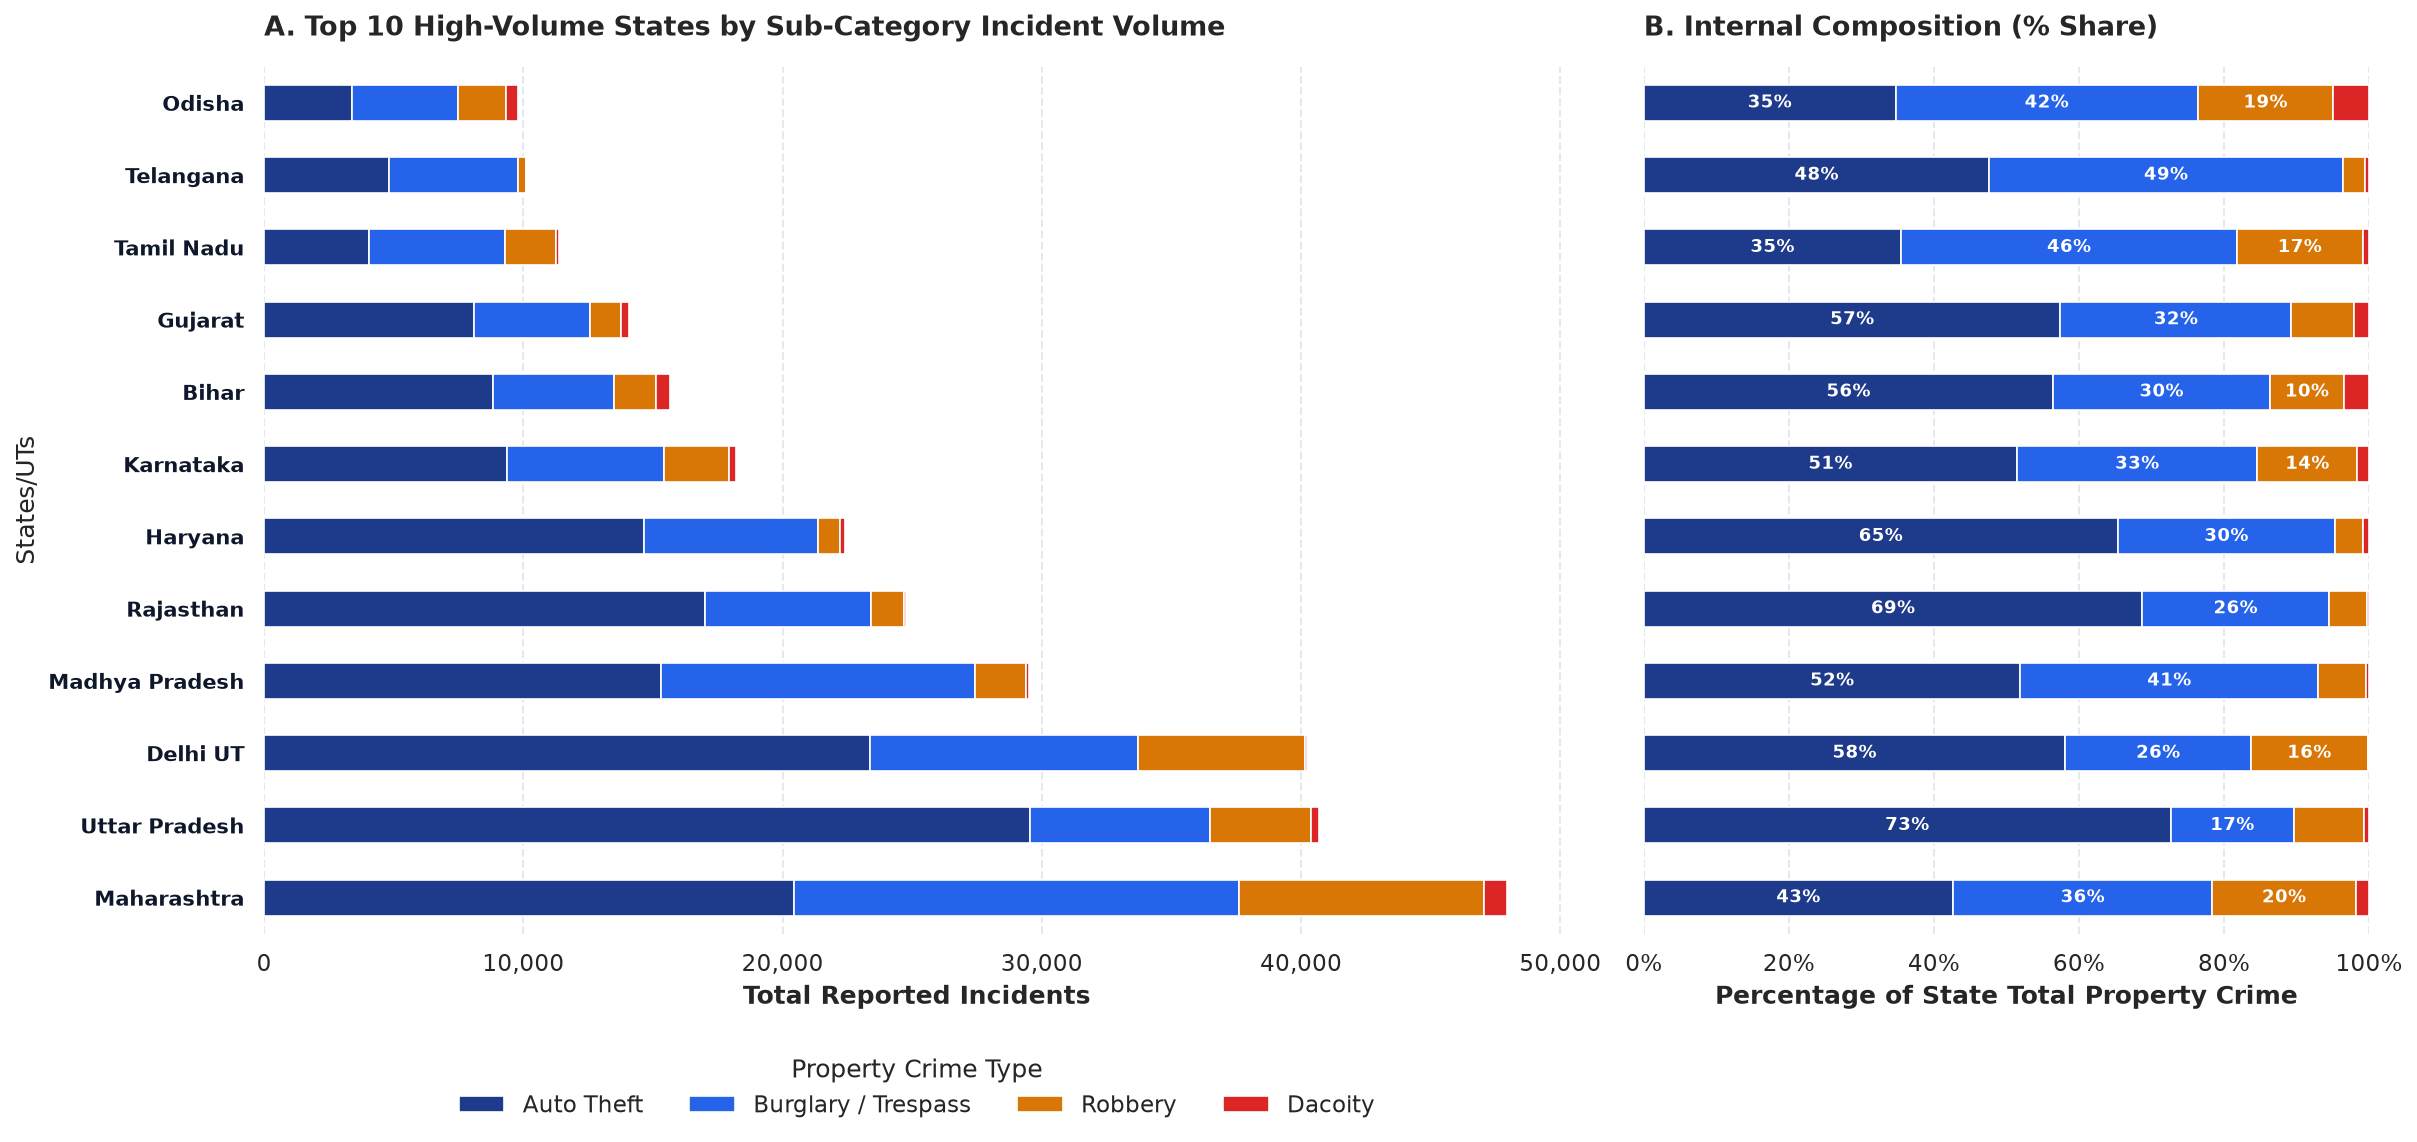

In [1074]:
df = property_crime.copy(deep=True)

df["Auto Theft"] = pd.to_numeric(df["Auto Theft"], errors="coerce").fillna(0)
df["Robbery"] = pd.to_numeric(df["Robbery"], errors="coerce").fillna(0)
df["Dacoity"] = pd.to_numeric(df["Dacoity"], errors="coerce").fillna(0)
df["Criminal Trespass/Burglary"] = pd.to_numeric(
    df["Criminal Trespass/Burglary"], errors="coerce"
).fillna(0)
df["Total Theft"] = pd.to_numeric(df["Total Theft"], errors="coerce").fillna(0)
df["pct_of_national_theft"] = pd.to_numeric(
    df["pct_of_national_theft"], errors="coerce"
).fillna(0)
df["pct_auto_in_state_theft"] = pd.to_numeric(
    df["pct_auto_in_state_theft"], errors="coerce"
).fillna(0)

top_12 = (
    df.sort_values(by="Total Theft", ascending=False).head(12).reset_index(drop=True)
)

sub_cols = [
    "Auto Theft",
    "Criminal Trespass/Burglary",
    "Robbery",
    "Dacoity",
]
clean_cols = [
    "Auto Theft",
    "Burglary / Trespass",
    "Robbery",
    "Dacoity",
]

property_colors = {
    "Auto Theft": "#1e3a8a",
    "Burglary / Trespass": "#2563eb",
    "Robbery": "#d97706",
    "Dacoity": "#dc2626",
}

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 7.5),
    dpi=150,
    sharey=True,
    layout="constrained",
    gridspec_kw={"width_ratios": [1.8, 1]},
)

y_pos = np.arange(len(top_12))

abs_plot_data = top_12.set_index("States/UTs")[sub_cols]
abs_plot_data.columns = clean_cols

abs_plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    color=[property_colors[c] for c in clean_cols],
    edgecolor="white",
    linewidth=0.8,
)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(
    top_12["States/UTs"], fontsize=10, fontweight="bold", color="#0f172a"
)
ax1.invert_yaxis()

ax1.set_title(
    "A. Top 10 High-Volume States by Sub-Category Incident Volume",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax1.set_xlabel("Total Reported Incidents", fontweight="bold")
ax1.xaxis.set_major_formatter("{x:,.0f}")
ax1.legend(
    title="Property Crime Type",
    bbox_to_anchor=(0.5, -0.12),
    loc="upper center",
    ncol=4,
    frameon=False,
)
sns.despine(ax=ax1, left=True, bottom=True)
ax1.xaxis.grid(True, linestyle="--", alpha=0.5, color="#cbd5e1")
ax1.set_axisbelow(True)

pct_data = top_12[sub_cols].div(top_12["Total Theft"], axis=0) * 100
pct_data.index = top_12["States/UTs"]
pct_data.columns = clean_cols

pct_data.plot(
    kind="barh",
    stacked=True,
    ax=ax2,
    color=[property_colors[c] for c in clean_cols],
    edgecolor="white",
    linewidth=0.8,
    legend=False,
)

ax2.set_title(
    "B. Internal Composition (% Share)",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax2.set_xlabel("Percentage of State Total Property Crime", fontweight="bold")
ax2.set_xlim(0, 100)
ax2.xaxis.set_major_formatter("{x:.0f}%")

for idx, row in pct_data.iterrows():
    cum_val = 0
    y_idx = list(top_12["States/UTs"]).index(idx)
    for col in clean_cols:
        val = row[col]
        if val >= 10:
            ax2.annotate(
                f"{val:.0f}%",
                (cum_val + val / 2.0, y_idx),
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color="white",
            )
        cum_val += val

sns.despine(ax=ax2, left=True, bottom=True)
ax2.xaxis.grid(True, linestyle="--", alpha=0.5, color="#cbd5e1")
ax2.set_axisbelow(True)

plt.show()

### 7. Public Order & Riot Breakdown

In [1075]:
riots_related_cols = []
riots_df = pd.DataFrame()
riots_df["states/UTs"] = df_state_totals["States/UTs"]
for col in df_state_totals.columns:
    if "Riots_" in col:
        riots_related_cols.append(col.lower())
        riots_df[col.lower()] = df_state_totals[col]

riots_df["total_riots"] = riots_df[riots_related_cols].sum(axis=1)

In [1076]:
riots_df = riots_df.sort_values(by="total_riots", ascending=False).reset_index()

TOTAL_RIOTS = riots_df["total_riots"].sum()

# Percentage of national total riots contributed by this state/UT
riots_df["pct_of_national_riots"] = np.round(
    riots_df["total_riots"] * 100 / TOTAL_RIOTS, 2
)

In [1077]:
riots_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   index                        36 non-null     int64  
 1   states/UTs                   36 non-null     str    
 2   riots_communal               36 non-null     int64  
 3   riots_industrial             36 non-null     int64  
 4   riots_political              36 non-null     int64  
 5   riots_caste conflict         36 non-null     int64  
 6   riots_sc/sts vs non-scs/sts  36 non-null     int64  
 7   riots_other caste conflict   36 non-null     int64  
 8   riots_agrarian               36 non-null     int64  
 9   riots_students               36 non-null     int64  
 10  riots_sectarian              36 non-null     int64  
 11  riots_others                 36 non-null     int64  
 12  total_riots                  36 non-null     int64  
 13  pct_of_national_riots        36 n

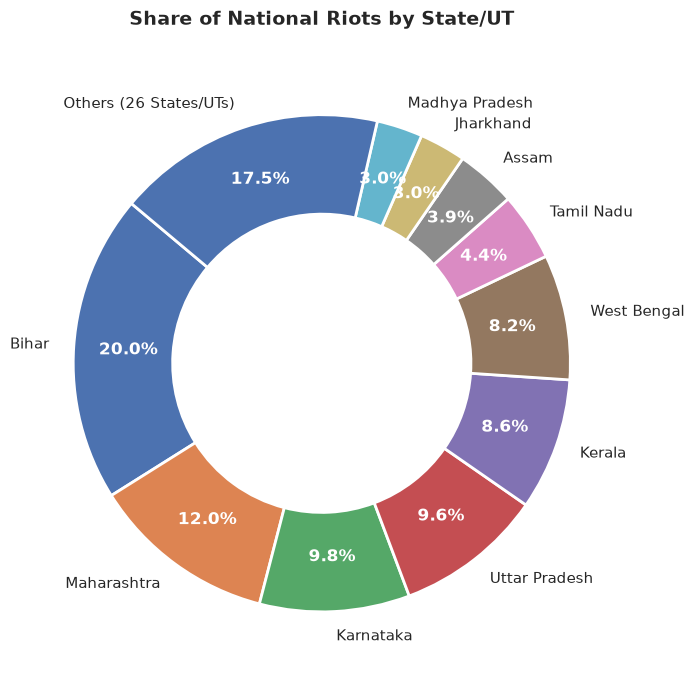

In [1078]:
df_sorted = riots_df.sort_values(by="pct_of_national_riots", ascending=False)

# Extract Top N states and aggregate the rest as "Others".
# There are too many states and plotting them inside of one pie chart will make it unreadable.
top_n = 10
df_top = df_sorted.iloc[:top_n].copy()
others_pct = df_sorted.iloc[top_n:]["pct_of_national_riots"].sum()

plot_df = pd.concat(
    [
        df_top[["states/UTs", "pct_of_national_riots"]],
        pd.DataFrame(
            [
                {
                    "states/UTs": f"Others ({len(riots_df) - top_n} States/UTs)",
                    "pct_of_national_riots": round(others_pct, 2),
                }
            ]
        ),
    ],
    ignore_index=True,
)

plt.figure(figsize=(9, 7), dpi=100)

wedges, texts, autotexts = plt.pie(
    plot_df["pct_of_national_riots"],
    labels=plot_df["states/UTs"],
    autopct="%1.1f%%",
    pctdistance=0.78,
    startangle=140,
    wedgeprops={
        "width": 0.4,
        "edgecolor": "white",
        "linewidth": 2,
    },  # NOTE: width < 1 creates the donut hole
)

for autotext in autotexts:
    autotext.set_weight("bold")
    autotext.set_color("white")

plt.title("Share of National Riots by State/UT", fontsize=14, pad=20, fontweight="bold")
plt.tight_layout()
plt.show()


### 8. Comprehensive Analysis of Crimes Against Women

In [1079]:
target_cols = [
    "Rape",
    "Attempt to commit Rape",
    "Dowry Deaths",
    "Cruelty by Husband or his Relatives",
    "Assault on Women with intent to outrage her Modesty",
    "Sexual Harassment",
    "Stalking",
    "Voyeurism",
    "Importation of Girls from Foreign Country",
]

crime_agnst_women = df_state_totals[["States/UTs"] + target_cols]
crime_agnst_women.columns = crime_agnst_women.columns.str.lower().str.replace(" ", "_")
target_cols = [col.lower().replace(" ", "_") for col in target_cols]

In [1080]:
TOTAL_CRIME_AGAINST_WOMEN = crime_agnst_women[target_cols].sum()
crime_agnst_women["total_crime_against_women"] = crime_agnst_women[target_cols].sum(
    axis=1
)

crime_agnst_women = crime_agnst_women.sort_values(
    by="total_crime_against_women",
    ascending=False,
).reset_index()

In [1081]:
crime_agnst_women.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 12 columns):
 #   Column                                               Non-Null Count  Dtype
---  ------                                               --------------  -----
 0   index                                                36 non-null     int64
 1   states/uts                                           36 non-null     str  
 2   rape                                                 36 non-null     int64
 3   attempt_to_commit_rape                               36 non-null     int64
 4   dowry_deaths                                         36 non-null     int64
 5   cruelty_by_husband_or_his_relatives                  36 non-null     int64
 6   assault_on_women_with_intent_to_outrage_her_modesty  36 non-null     int64
 7   sexual_harassment                                    36 non-null     int64
 8   stalking                                             36 non-null     int64
 9   voyeurism              

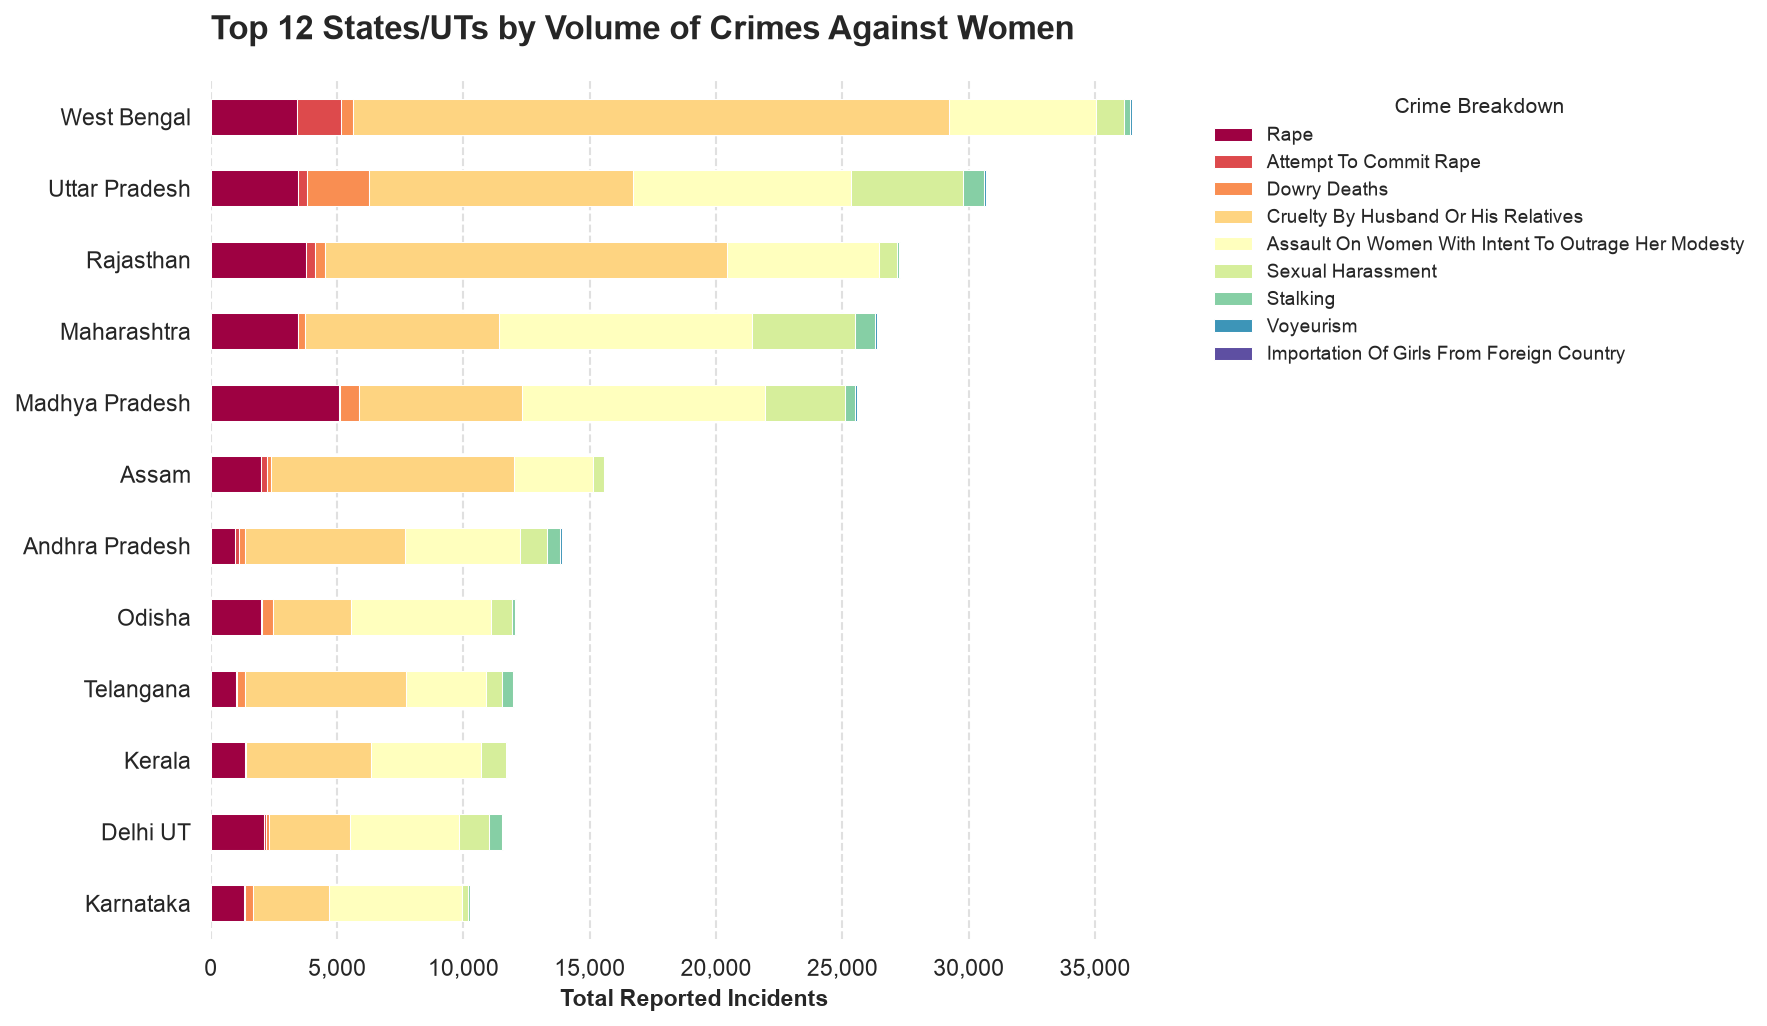

In [1082]:
df = crime_agnst_women.copy(deep=True)

sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["font.family"] = "sans-serif"

exclude_cols = ["index", "states/uts", "total_crime_against_women"]
feature_cols = [col for col in crime_agnst_women.columns if col not in exclude_cols]

top_12 = df.sort_values(by="total_crime_against_women", ascending=False).head(12)

plot_data = top_12.set_index("states/uts")[feature_cols]

plot_data.columns = [col.replace("_", " ").title() for col in plot_data.columns]

fig, ax = plt.subplots(figsize=(12, 7), dpi=150)

plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    colormap="Spectral",
    edgecolor="white",
    linewidth=0.5,
)

ax.invert_yaxis()  # NOTE: Highest total at top
ax.set_title(
    "Top 12 States/UTs by Volume of Crimes Against Women",
    fontsize=16,
    fontweight="bold",
    pad=20,
    loc="left",
)
ax.set_xlabel("Total Reported Incidents", fontsize=11, fontweight="bold")
ax.set_ylabel("", fontsize=11)

ax.xaxis.set_major_formatter("{x:,.0f}")

sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle="--", alpha=0.6)
ax.yaxis.grid(False)

ax.legend(
    title="Crime Breakdown",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

plt.tight_layout()
plt.show()


### 9. Micro-Analysis of Rape Sub-Categories

In [1083]:
rape_cols = [col for col in df_state_totals.columns if "Rape" in col]
rape_df = df_state_totals[["States/UTs"] + rape_cols].drop(
    columns=["Rape", "Rape other than Custodial"]
)

In [1084]:
rape_cols.remove("Rape")
rape_cols.remove("Rape other than Custodial")

TOTAL_RAPE_INCIDENTS = rape_df[rape_cols].sum()
rape_df["rape_incidents"] = rape_df[rape_cols].sum(axis=1)

In [1085]:
rape_df = (
    rape_df.sort_values(
        by="rape_incidents",
        ascending=False,
    )
    .reset_index()
    .drop(columns="index")
)

In [1086]:
rape_df.head()

,States/UTs,Custodial Rape,Custodial_Gang Rape,Custodial_Other Rape,Rape_Gang Rape,Rape_Others,Attempt to commit Rape,rape_incidents
0,West Bengal,1,0,1,184,3224,1732,5142
1,Madhya Pradesh,0,0,0,284,4792,56,5132
2,Rajasthan,3,2,1,414,3342,373,4135
3,Uttar Pradesh,189,5,184,573,2705,324,3980
4,Maharashtra,0,0,0,126,3312,15,3453


In [1087]:
# NOTE: "Rape_Others" column will be dropped
# because it provides no value while distorting analysis/graphs.

rape_df = rape_df.drop(columns="Rape_Others")

In [1088]:
rape_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   States/UTs              36 non-null     str  
 1   Custodial Rape          36 non-null     int64
 2   Custodial_Gang Rape     36 non-null     int64
 3   Custodial_Other Rape    36 non-null     int64
 4   Rape_Gang Rape          36 non-null     int64
 5   Attempt to commit Rape  36 non-null     int64
 6   rape_incidents          36 non-null     int64
dtypes: int64(6), str(1)
memory usage: 2.1 KB


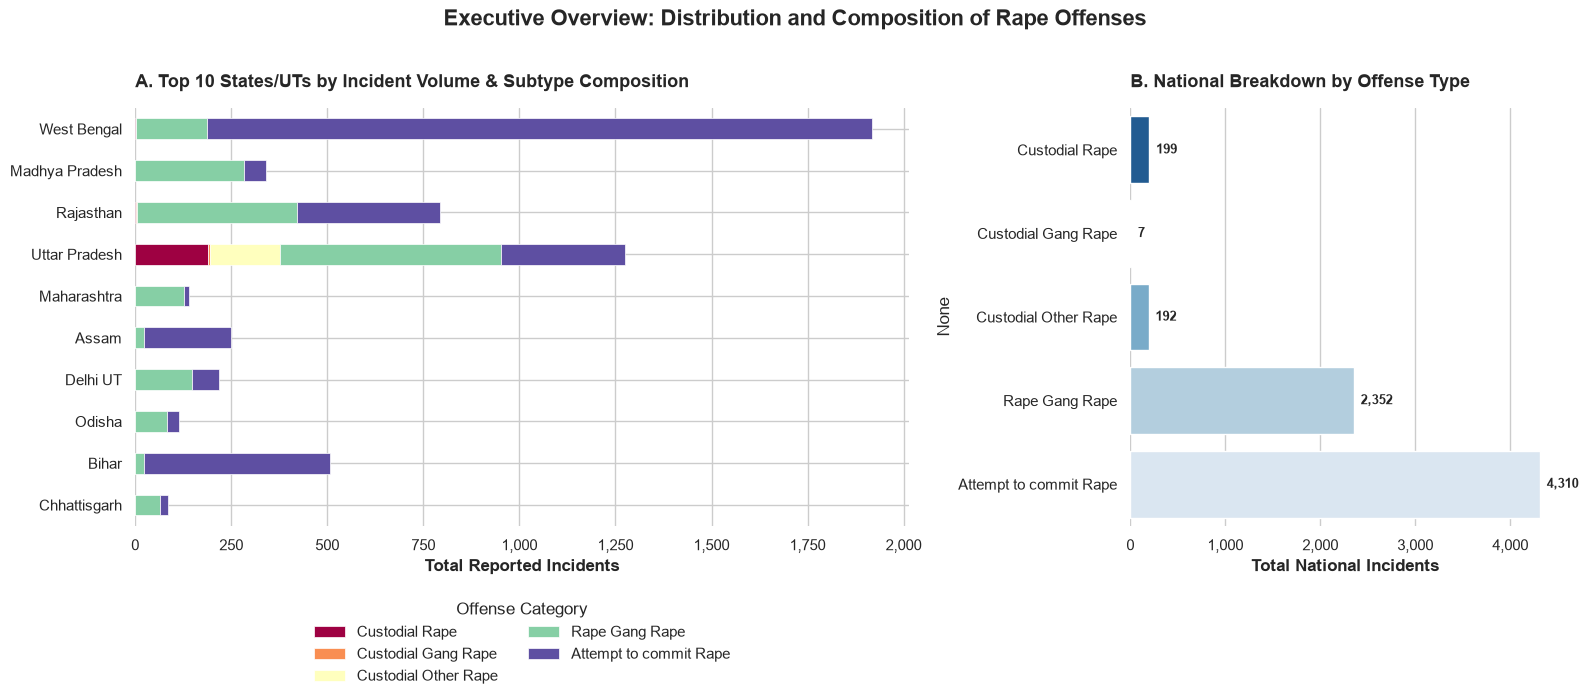

In [1089]:
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["font.size"] = 10

sub_categories = [
    "Custodial Rape",
    "Custodial_Gang Rape",
    "Custodial_Other Rape",
    "Rape_Gang Rape",
    "Attempt to commit Rape",
]

clean_labels = [c.replace("_", " ") for c in sub_categories]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.8, 1]}
)

top_10 = rape_df.sort_values(by="rape_incidents", ascending=False).head(10)
plot_data = top_10.set_index("States/UTs")[sub_categories]
plot_data.columns = clean_labels

plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    colormap="Spectral",
    edgecolor="white",
    linewidth=0.5,
)

ax1.invert_yaxis()
ax1.set_title(
    "A. Top 10 States/UTs by Incident Volume & Subtype Composition",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax1.set_xlabel("Total Reported Incidents", fontweight="bold")
ax1.set_ylabel("")
ax1.xaxis.set_major_formatter("{x:,.0f}")
ax1.legend(
    title="Offense Category",
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=2,
    frameon=False,
)
sns.despine(ax=ax1, left=True, bottom=True)

national_totals = rape_df[sub_categories].sum()
national_totals.index = clean_labels

sns.barplot(
    x=national_totals.values,
    y=national_totals.index,
    hue=national_totals.index,
    legend=False,
    ax=ax2,
    palette="Blues_r",
    orient="h",
)

ax2.set_title(
    "B. National Breakdown by Offense Type",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax2.set_xlabel("Total National Incidents", fontweight="bold")
ax2.xaxis.set_major_formatter("{x:,.0f}")

for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(
        f"{int(width):,}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

sns.despine(ax=ax2, left=True, bottom=True)

plt.suptitle(
    "Executive Overview: Distribution and Composition of Rape Offenses",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


### 10. Financial & White-Collar Crime Patterns

In [1090]:
# NOTE: Main financial and white-collar crime categories
financial_crime_main_cols = [
    "Cheating",
    "Forgery",
    "Criminal Breach of Trust",
    "Extortion",
    "Counterfeiting",
]

# NOTE: Specific sub-categories related to counterfeiting & currency
counterfeiting_sub_cols = [
    "Counterfeit Offences related to Counterfeit Coin",
    "Counterfeiting Government Stamp",
    "Counterfeit currency & Bank notes",
    "Counterfeiting currency notes/Bank notes",
    "Using forged or counterfeiting currency/Bank notes",
    "Possession of forged or counterfeiting currency/Bank notes",
    "Making or Possessing materials for forged currency/Bank notes",
    "Making or Using documents resembling currency",
]

all_financial_crime_cols = financial_crime_main_cols + counterfeiting_sub_cols

In [1091]:
financial_crime_df = df_state_totals[["States/UTs"] + financial_crime_main_cols]
financial_crime_df["total_crimes"] = financial_crime_df[financial_crime_main_cols].sum(
    axis=1
)
financial_crime_df = (
    financial_crime_df.sort_values(by="total_crimes", ascending=False)
    .reset_index()
    .drop(columns="index")
)
TOTAL_FINANCIAL_CRIMES = financial_crime_df[financial_crime_main_cols].sum()


In [1092]:
financial_crime_df.head()

,States/UTs,Cheating,Forgery,Criminal Breach of Trust,Extortion,Counterfeiting,total_crimes
0,Rajasthan,21191,4316,657,428,57,26649
1,Uttar Pradesh,10636,569,4074,609,111,15999
2,Maharashtra,9959,1293,1958,780,201,14191
3,West Bengal,7239,570,2028,555,359,10751
4,Telangana,8519,191,635,171,68,9584


In [1093]:
financial_crime_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   States/UTs                36 non-null     str  
 1   Cheating                  36 non-null     int64
 2   Forgery                   36 non-null     int64
 3   Criminal Breach of Trust  36 non-null     int64
 4   Extortion                 36 non-null     int64
 5   Counterfeiting            36 non-null     int64
 6   total_crimes              36 non-null     int64
dtypes: int64(6), str(1)
memory usage: 2.1 KB


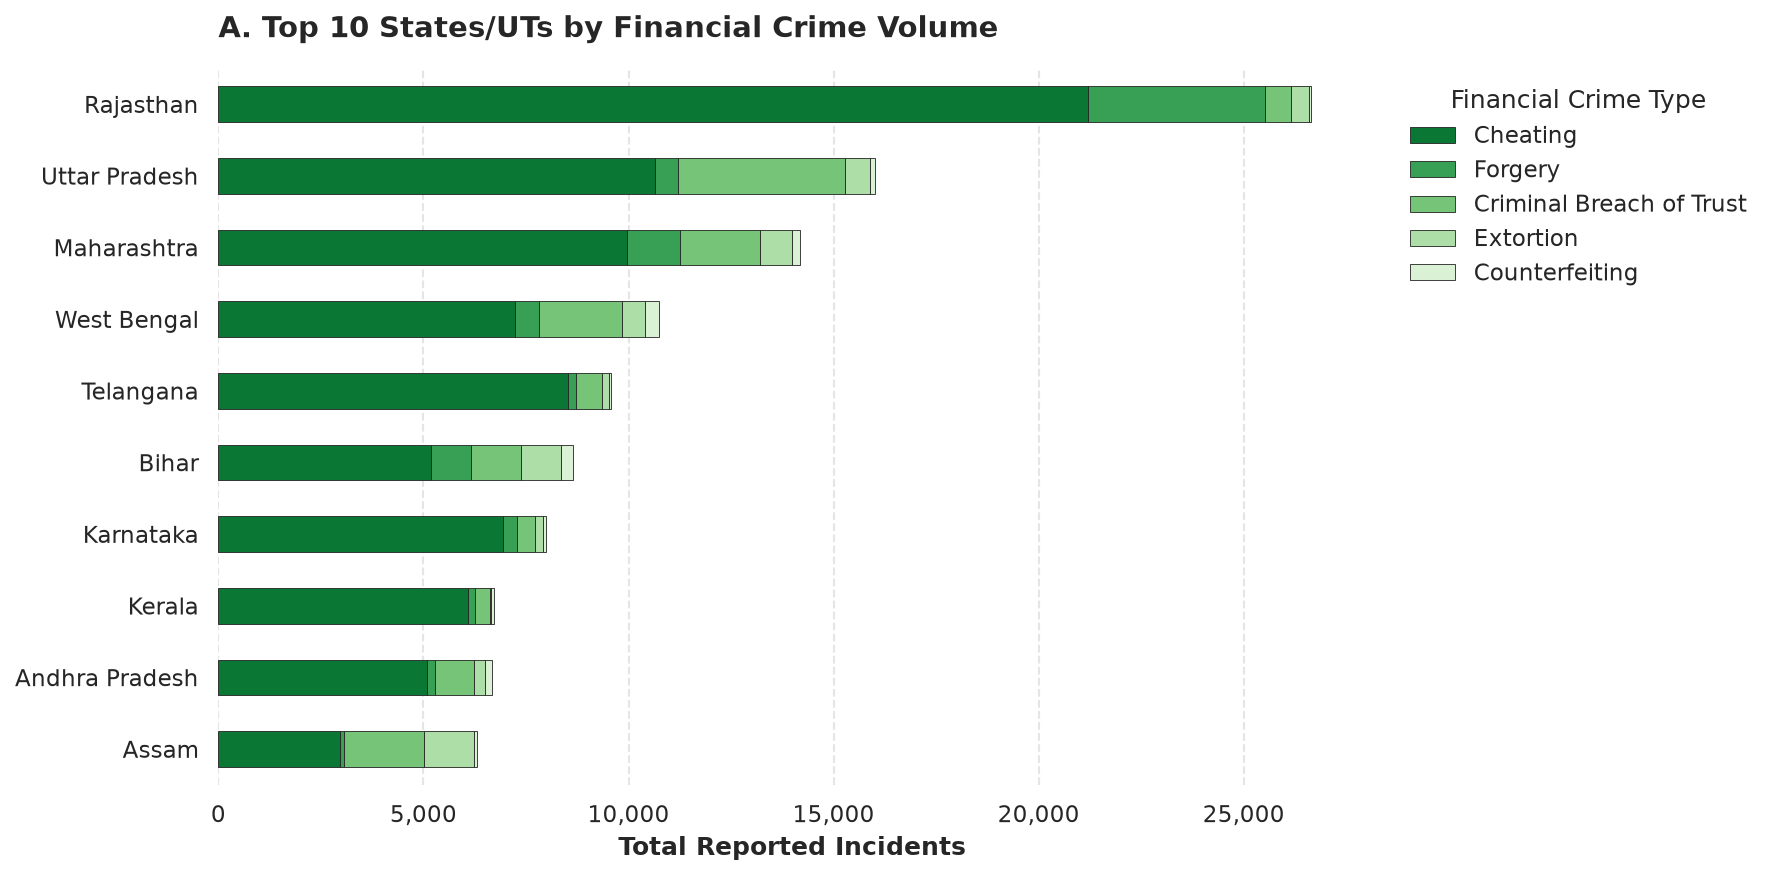

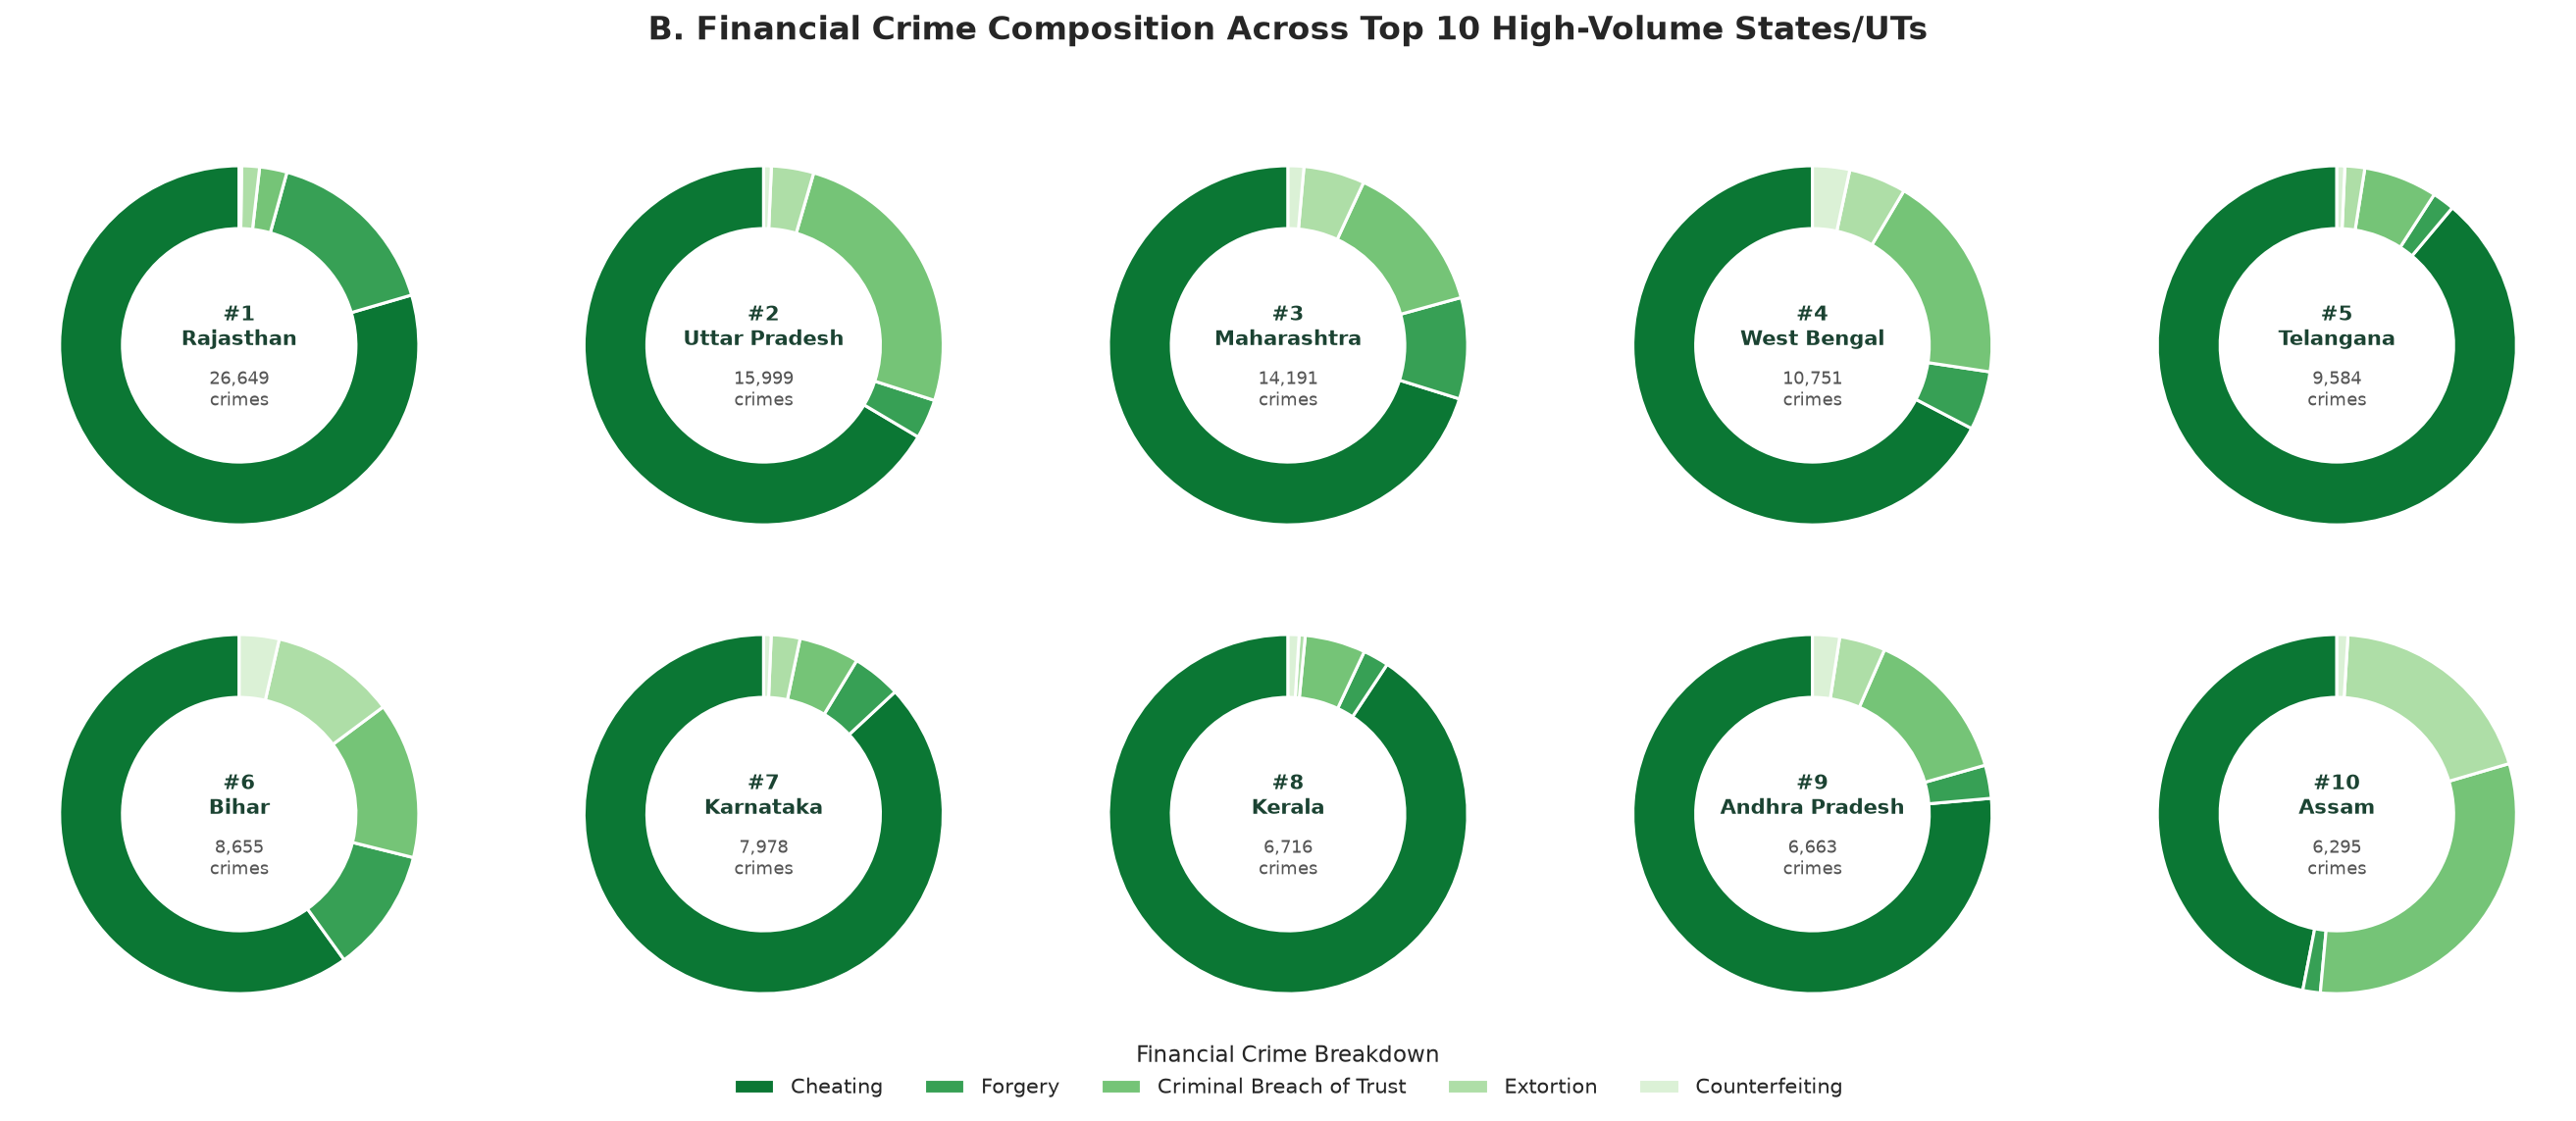

In [1094]:
df = financial_crime_df.copy(deep=True)

sns.set_theme(style="white", font="sans-serif")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

crime_cats = [
    "Cheating",
    "Forgery",
    "Criminal Breach of Trust",
    "Extortion",
    "Counterfeiting",
]

for col in crime_cats + ["total_crimes"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

top_10 = (
    df.sort_values(by="total_crimes", ascending=False).head(10).reset_index(drop=True)
)

colors = sns.color_palette("Greens_r", n_colors=len(crime_cats))
category_colors = dict(zip(crime_cats, colors))

fig1, ax1 = plt.subplots(figsize=(12, 6), dpi=150)

plot_data = top_10.set_index("States/UTs")[crime_cats]
plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    color=[category_colors[c] for c in crime_cats],
    edgecolor="#222222",
    linewidth=0.4,
)

ax1.invert_yaxis()
ax1.set_title(
    "A. Top 10 States/UTs by Financial Crime Volume",
    fontsize=14,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax1.set_xlabel("Total Reported Incidents", fontweight="bold")
ax1.set_ylabel("")
ax1.xaxis.set_major_formatter("{x:,.0f}")
ax1.legend(
    title="Financial Crime Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)
sns.despine(left=True, bottom=True)
ax1.xaxis.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

fig2, axes = plt.subplots(2, 5, figsize=(18, 7), dpi=150)
axes = axes.flatten()

for idx, row in top_10.iterrows():
    ax = axes[idx]
    state_name = row["States/UTs"]
    values = row[crime_cats].values.astype(float)
    total_val = row["total_crimes"]

    wedges, _ = ax.pie(
        values,
        startangle=90,
        colors=[category_colors[c] for c in crime_cats],
        wedgeprops={"width": 0.35, "edgecolor": "white", "linewidth": 1.5},
    )

    ax.text(
        0,
        0.1,
        f"#{idx + 1}\n{state_name}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#1b4332",
    )
    ax.text(
        0,
        -0.25,
        f"{total_val:,.0f}\ncrimes",
        ha="center",
        va="center",
        fontsize=8.5,
        color="#555555",
    )

fig2.legend(
    wedges,
    crime_cats,
    title="Financial Crime Breakdown",
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=10,
    title_fontsize=11,
    bbox_to_anchor=(0.5, -0.05),
)

plt.suptitle(
    "B. Financial Crime Composition Across Top 10 High-Volume States/UTs",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### 11. Kidnapping & Abduction Intent Analysis

In [1095]:
kidnapping_reason_cols = [
    "Kidnapping & Abduction",
    "Kidnapping & Abduction in order to Murder",
    "Kidnapping for Ransom",
    "Kidnapping & Abduction of Women to compel her for marriage",
    "Other Kidnapping",
]

kidnapping_df = df_state_totals[["States/UTs"] + kidnapping_reason_cols]
kidnapping_df["total_kidnaps"] = kidnapping_df[kidnapping_reason_cols].sum(axis=1)
kidnapping_df = kidnapping_df.sort_values(
    by="total_kidnaps",
    ascending=False,
).reset_index()

In [1096]:
kidnapping_df.head()


,index,States/UTs,Kidnapping & Abduction,Kidnapping & Abduction in order to Murder,Kidnapping for Ransom,Kidnapping & Abduction of Women to compel her for marriage,Other Kidnapping,total_kidnaps
0,756,Uttar Pradesh,2795,539,82,7338,1607,12361
1,405,Madhya Pradesh,3224,19,31,2364,2195,7833
2,801,West Bengal,2435,53,106,1508,3183,7285
3,832,Delhi UT,6651,0,38,2,452,7143
4,116,Bihar,518,632,62,4641,717,6570


In [1097]:
kidnapping_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column                                                      Non-Null Count  Dtype
---  ------                                                      --------------  -----
 0   index                                                       36 non-null     int64
 1   States/UTs                                                  36 non-null     str  
 2   Kidnapping & Abduction                                      36 non-null     int64
 3   Kidnapping & Abduction in order to Murder                   36 non-null     int64
 4   Kidnapping for Ransom                                       36 non-null     int64
 5   Kidnapping & Abduction of Women to compel her for marriage  36 non-null     int64
 6   Other Kidnapping                                            36 non-null     int64
 7   total_kidnaps                                               36 non-null     int64
dtypes: int64(7), str(1)
memory usage: 

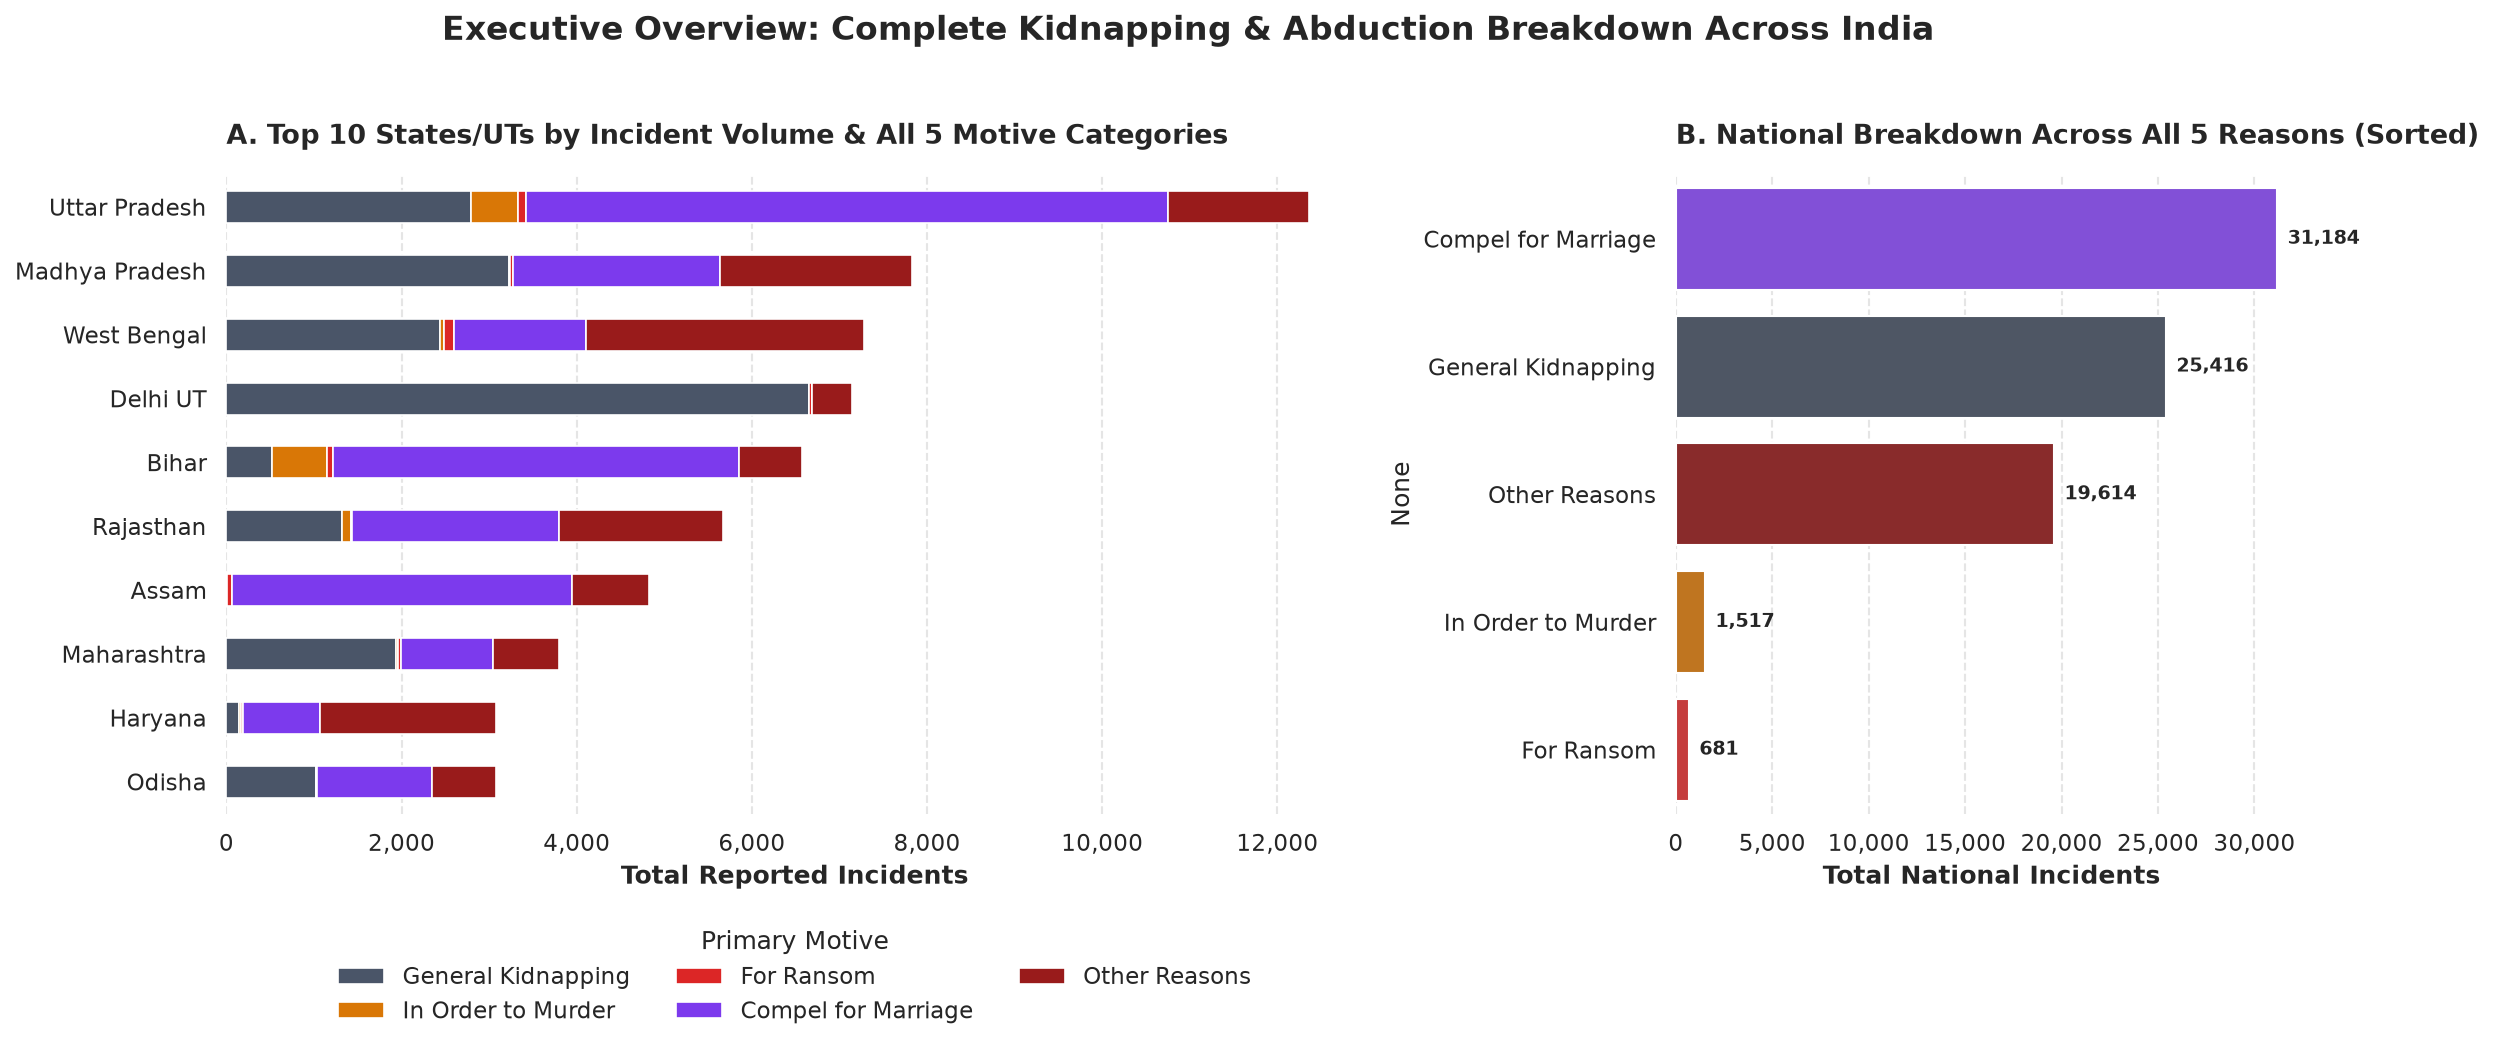

In [1098]:
df = kidnapping_df.copy(deep=True)

sns.set_theme(style="white", font="sans-serif")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

motive_cols = [
    "Kidnapping & Abduction",
    "Kidnapping & Abduction in order to Murder",
    "Kidnapping for Ransom",
    "Kidnapping & Abduction of Women to compel her for marriage",
    "Other Kidnapping",
]

clean_labels = [
    "General Kidnapping",
    "In Order to Murder",
    "For Ransom",
    "Compel for Marriage",
    "Other Reasons",
]

for col in motive_cols + ["total_kidnaps"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

top_10 = (
    df.sort_values(by="total_kidnaps", ascending=False).head(10).reset_index(drop=True)
)

alert_colors = ["#4a5568", "#d97706", "#dc2626", "#7c3aed", "#991b1b"]
motive_color_map = dict(zip(clean_labels, alert_colors))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 7), dpi=150, gridspec_kw={"width_ratios": [1.8, 1]}
)

plot_data = top_10.set_index("States/UTs")[motive_cols]
plot_data.columns = clean_labels

plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    color=[motive_color_map[c] for c in clean_labels],
    edgecolor="white",
    linewidth=0.8,
)

ax1.invert_yaxis()
ax1.set_title(
    "A. Top 10 States/UTs by Incident Volume & All 5 Motive Categories",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax1.set_xlabel("Total Reported Incidents", fontweight="bold")
ax1.set_ylabel("")
ax1.xaxis.set_major_formatter("{x:,.0f}")
ax1.legend(
    title="Primary Motive",
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=3,
    frameon=False,
)
sns.despine(ax=ax1, left=True, bottom=True)
ax1.xaxis.grid(True, linestyle="--", alpha=0.5)

national_totals = (
    df[motive_cols]
    .sum()
    .rename(dict(zip(motive_cols, clean_labels)))
    .sort_values(ascending=False)
)

sns.barplot(
    x=national_totals.values,
    y=national_totals.index,
    hue=national_totals.index,
    legend=False,
    ax=ax2,
    palette=[motive_color_map[c] for c in national_totals.index],
    orient="h",
)

ax2.set_title(
    "B. National Breakdown Across All 5 Reasons (Sorted)",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax2.set_xlabel("Total National Incidents", fontweight="bold")
ax2.xaxis.set_major_formatter("{x:,.0f}")

for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(
        f"{int(width):,}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

sns.despine(ax=ax2, left=True, bottom=True)
ax2.xaxis.grid(True, linestyle="--", alpha=0.5)

plt.suptitle(
    "Executive Overview: Complete Kidnapping & Abduction Breakdown Across India",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### 12. Crime Category Proportional Matrix

In [1099]:
# NOTE: Main financial crime categories
financial_crime_main_cols = [
    "Cheating",
    "Forgery",
    "Criminal Breach of Trust",
    "Extortion",
    "Counterfeiting",
]

# NOTE: Specific sub-categories related to counterfeiting & currency
counterfeiting_sub_cols = [
    "Counterfeit Offences related to Counterfeit Coin",
    "Counterfeiting Government Stamp",
    "Counterfeit currency & Bank notes",
    "Counterfeiting currency notes/Bank notes",
    "Using forged or counterfeiting currency/Bank notes",
    "Possession of forged or counterfeiting currency/Bank notes",
    "Making or Possessing materials for forged currency/Bank notes",
    "Making or Using documents resembling currency",
]

all_financial_crime_cols = financial_crime_main_cols + counterfeiting_sub_cols

# NOTE: Financial crimes DataFrame extraction
financial_cols_full = [
    "States/UTs",
    "Total Cognizable IPC crimes",
] + all_financial_crime_cols
financial_crime_df = (
    df_state_totals[financial_cols_full].copy(deep=True).sort_values(by="States/UTs")
)
financial_crime_df["total_financial_crime"] = df_state_totals[
    all_financial_crime_cols
].sum(axis=1)

In [1100]:
crime_against_women_cols = [
    "Rape",
    "Attempt to commit Rape",
    "Dowry Deaths",
    "Cruelty by Husband or his Relatives",
    "Assault on Women with intent to outrage her Modesty",
    "Sexual Harassment",
    "Stalking",
    "Voyeurism",
    "Importation of Girls from Foreign Country",
]

property_crime_cols = [
    "Auto Theft",
    "Theft",
    "Robbery",
    "Dacoity",
    "Criminal Trespass/Burglary",
]

In [1101]:
women_cols_full = [
    "States/UTs",
    "Total Cognizable IPC crimes",
] + crime_against_women_cols
women_crime_df = (
    df_state_totals[women_cols_full].copy(deep=True).sort_values(by="States/UTs")
)
women_crime_df["total_crime_against_women"] = df_state_totals[
    crime_against_women_cols
].sum(axis=1)

property_cols_full = [
    "States/UTs",
    "Total Cognizable IPC crimes",
] + property_crime_cols
property_crime_df = (
    df_state_totals[property_cols_full].copy(deep=True).sort_values(by="States/UTs")
)
property_crime_df["total_property_crime"] = df_state_totals[property_crime_cols].sum(
    axis=1
)

In [1102]:
women_crime_df.head()

,States/UTs,Total Cognizable IPC crimes,Rape,Attempt to commit Rape,Dowry Deaths,Cruelty by Husband or his Relatives,Assault on Women with intent to outrage her Modesty,Sexual Harassment,Stalking,Voyeurism,Importation of Girls from Foreign Country,total_crime_against_women
805,A&N Islands,746,32,0,3,14,41,18,4,1,0,113
20,Andhra Pradesh,114604,961,165,215,6362,4547,1072,504,71,0,13897
40,Arunachal Pradesh,2843,83,10,1,42,121,21,1,6,0,285
69,Assam,94337,1980,227,188,9626,3099,458,0,0,1,15579
116,Bihar,177595,1127,484,1373,4672,572,271,7,4,5,8515


In [1103]:
property_crime_df.head()

,States/UTs,Total Cognizable IPC crimes,Auto Theft,Theft,Robbery,Dacoity,Criminal Trespass/Burglary,total_property_crime
805,A&N Islands,746,4,45,2,0,64,115
20,Andhra Pradesh,114604,4540,15617,433,75,4719,25384
40,Arunachal Pradesh,2843,158,498,61,12,224,953
69,Assam,94337,3498,12737,1038,267,4954,22494
116,Bihar,177595,8828,22888,1600,538,4674,38528


In [1104]:
crime_matrix = pd.DataFrame()
crime_matrix["States/UTs"] = property_crime_df["States/UTs"]
crime_matrix["total_crime_against_women"] = women_crime_df["total_crime_against_women"]
crime_matrix["total_property_crime"] = property_crime_df["total_property_crime"]
crime_matrix["total_financial_crime"] = financial_crime_df["total_financial_crime"]
crime_matrix["Total Cognizable IPC crimes"] = women_crime_df[
    "Total Cognizable IPC crimes"
]

In [1105]:
crime_matrix.head()

,States/UTs,total_crime_against_women,total_property_crime,total_financial_crime,Total Cognizable IPC crimes
805,A&N Islands,113,115,84,746
20,Andhra Pradesh,13897,25384,6981,114604
40,Arunachal Pradesh,285,953,274,2843
69,Assam,15579,22494,6418,94337
116,Bihar,8515,38528,8981,177595


In [1106]:
crime_matrix.info()

<class 'pandas.DataFrame'>
Index: 36 entries, 805 to 801
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   States/UTs                   36 non-null     str  
 1   total_crime_against_women    36 non-null     int64
 2   total_property_crime         36 non-null     int64
 3   total_financial_crime        36 non-null     int64
 4   Total Cognizable IPC crimes  36 non-null     int64
dtypes: int64(4), str(1)
memory usage: 1.7 KB


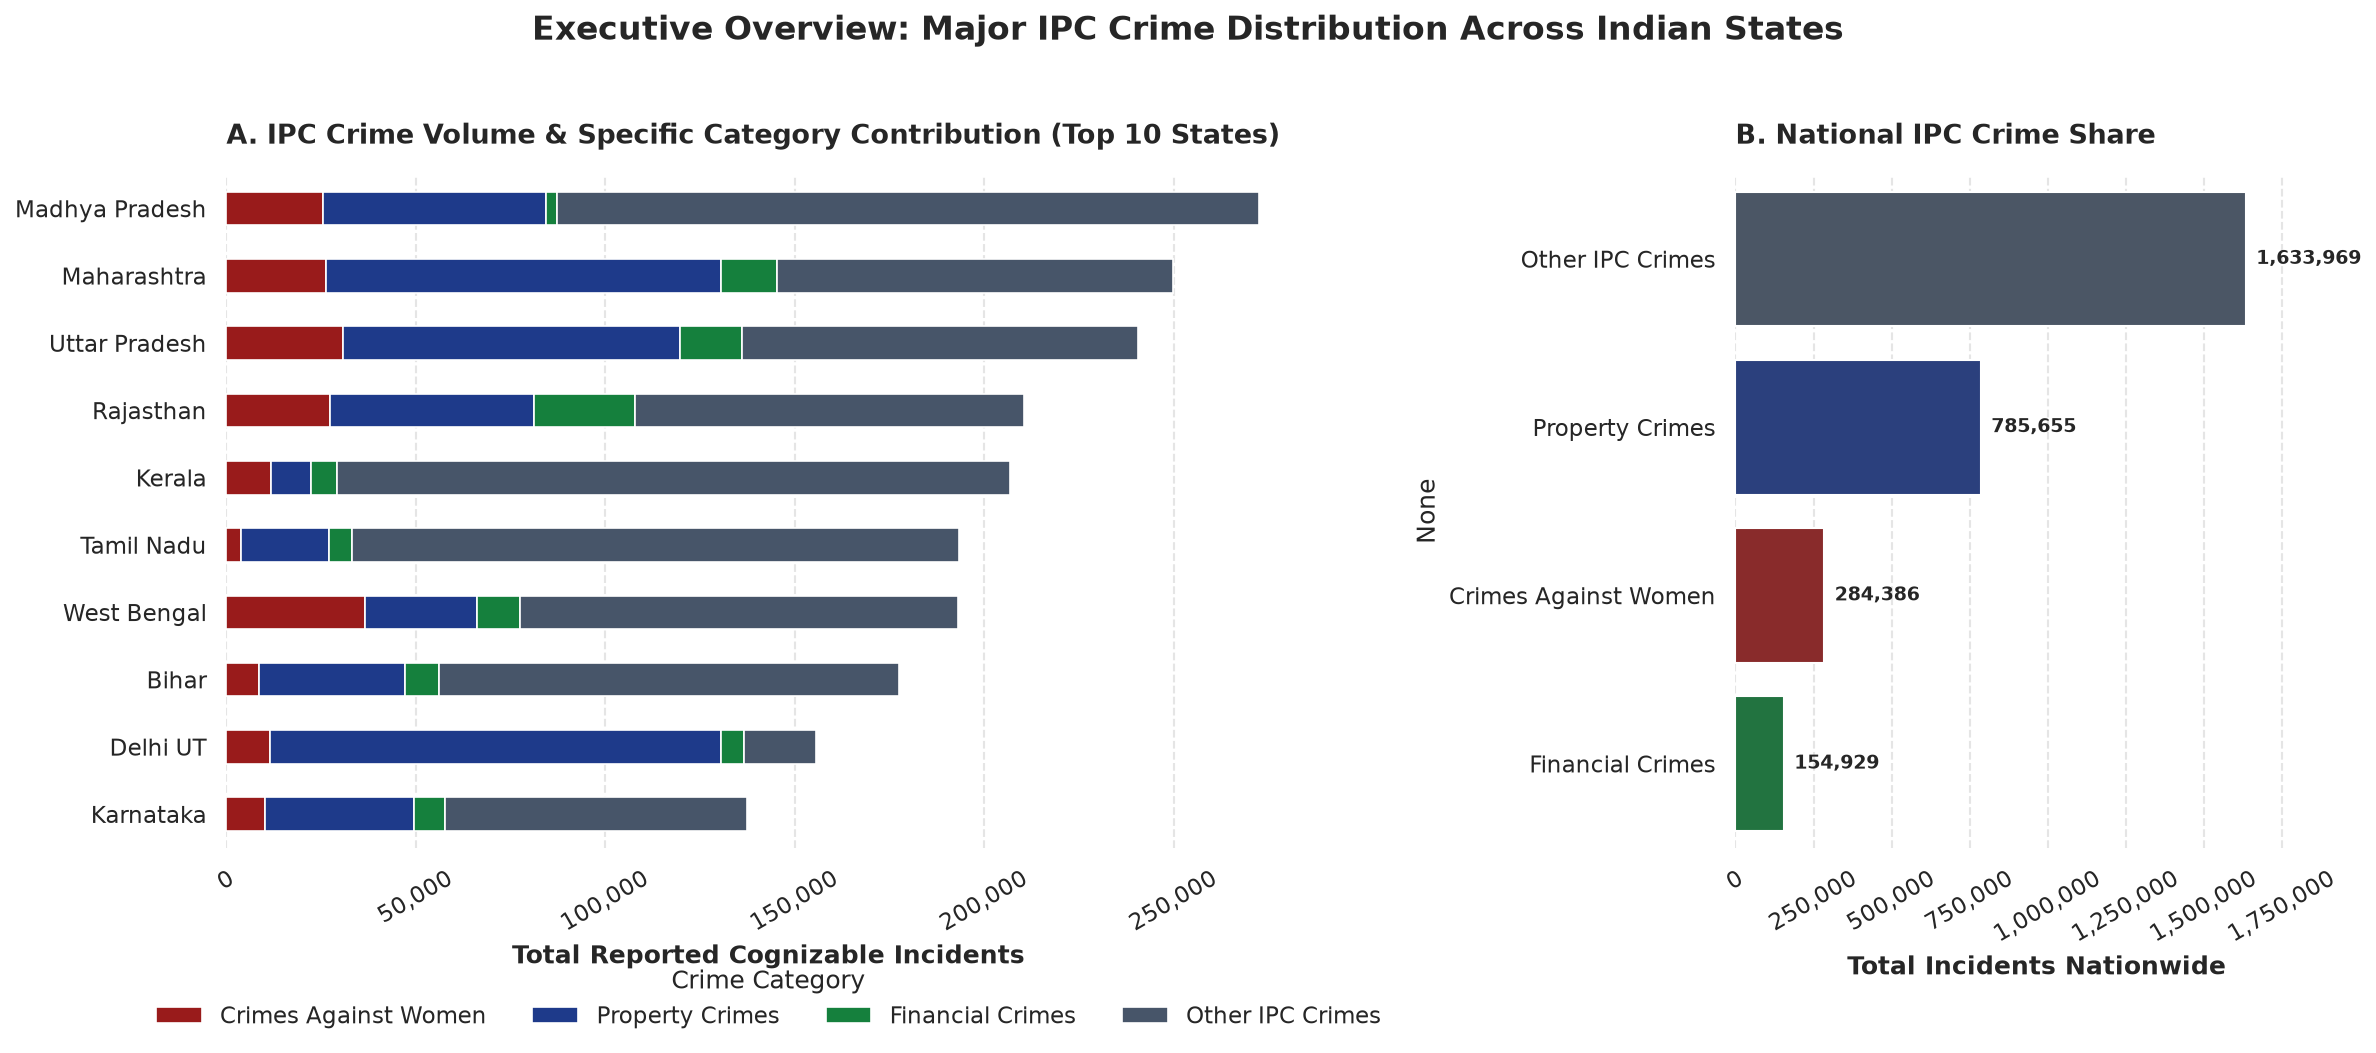

In [1107]:
df = crime_matrix.copy(deep=True)

df["total_crime_against_women"] = pd.to_numeric(
    df["total_crime_against_women"], errors="coerce"
).fillna(0)
df["total_property_crime"] = pd.to_numeric(
    df["total_property_crime"], errors="coerce"
).fillna(0)
df["total_financial_crime"] = pd.to_numeric(
    df["total_financial_crime"], errors="coerce"
).fillna(0)
df["Total Cognizable IPC crimes"] = pd.to_numeric(
    df["Total Cognizable IPC crimes"], errors="coerce"
).fillna(0)

df["other_ipc_crimes"] = (
    df["Total Cognizable IPC crimes"]
    - df["total_crime_against_women"]
    - df["total_property_crime"]
    - df["total_financial_crime"]
).clip(lower=0)

top_10 = (
    df.sort_values(by="Total Cognizable IPC crimes", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

category_colors = {
    "Crimes Against Women": "#991b1b",
    "Property Crimes": "#1e3a8a",
    "Financial Crimes": "#15803d",
    "Other IPC Crimes": "#475569",
}

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 7), dpi=150, gridspec_kw={"width_ratios": [1.8, 1]}
)

plot_data = top_10.set_index("States/UTs")[
    [
        "total_crime_against_women",
        "total_property_crime",
        "total_financial_crime",
        "other_ipc_crimes",
    ]
]
plot_data.columns = [
    "Crimes Against Women",
    "Property Crimes",
    "Financial Crimes",
    "Other IPC Crimes",
]

plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    color=[category_colors[c] for c in plot_data.columns],
    edgecolor="white",
    linewidth=0.8,
)

ax1.invert_yaxis()
ax1.set_title(
    "A. IPC Crime Volume & Specific Category Contribution (Top 10 States)",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax1.set_xlabel("Total Reported Cognizable Incidents", fontweight="bold")
ax1.set_ylabel("")
ax1.xaxis.set_major_formatter("{x:,.0f}")
ax1.legend(
    title="Crime Category",
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=4,
    frameon=False,
)
sns.despine(ax=ax1, left=True, bottom=True)
ax1.xaxis.grid(True, linestyle="--", alpha=0.5)

national_totals = pd.Series(
    {
        "Crimes Against Women": df["total_crime_against_women"].sum(),
        "Property Crimes": df["total_property_crime"].sum(),
        "Financial Crimes": df["total_financial_crime"].sum(),
        "Other IPC Crimes": df["other_ipc_crimes"].sum(),
    }
).sort_values(ascending=False)

sns.barplot(
    x=national_totals.values,
    y=national_totals.index,
    hue=national_totals.index,
    legend=False,
    ax=ax2,
    palette=[category_colors[c] for c in national_totals.index],
    orient="h",
)

ax2.set_title(
    "B. National IPC Crime Share",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax2.set_xlabel("Total Incidents Nationwide", fontweight="bold")
ax2.xaxis.set_major_formatter("{x:,.0f}")

max_x = national_totals.max()
ax2.set_xlim(0, max_x * 1.18)

for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(
        f"{int(width):,}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

ax1.tick_params(axis="x", rotation=30)
ax2.tick_params(axis="x", rotation=30)

sns.despine(ax=ax2, left=True, bottom=True)
ax2.xaxis.grid(True, linestyle="--", alpha=0.5)

plt.suptitle(
    "Executive Overview: Major IPC Crime Distribution Across Indian States",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### 13. District Risk Tier Classification (Clustering / Binning)

In [1108]:
risk_tier_classification_df: pd.DataFrame = (
    df_state_totals[["States/UTs", "Total Cognizable IPC crimes"]]
    .sort_values(by="Total Cognizable IPC crimes", ascending=False)
    .reset_index()
    .drop(columns="index")
)

In [1109]:
risk_tier_classification_df["crime_tier"]: pd.Series = pd.qcut(
    risk_tier_classification_df["Total Cognizable IPC crimes"],
    4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical",
    ],
)

In [1110]:
risk_tier_classification_df.head(10)

,States/UTs,Total Cognizable IPC crimes,crime_tier
0,Madhya Pradesh,272423,Critical
1,Maharashtra,249834,Critical
2,Uttar Pradesh,240475,Critical
3,Rajasthan,210418,Critical
4,Kerala,206789,Critical
5,Tamil Nadu,193200,Critical
6,West Bengal,193048,Critical
7,Bihar,177595,Critical
8,Delhi UT,155654,Critical
9,Karnataka,137338,High


In [1111]:
risk_tier_classification_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   States/UTs                   36 non-null     str     
 1   Total Cognizable IPC crimes  36 non-null     int64   
 2   crime_tier                   36 non-null     category
dtypes: category(1), int64(1), str(1)
memory usage: 948.0 bytes


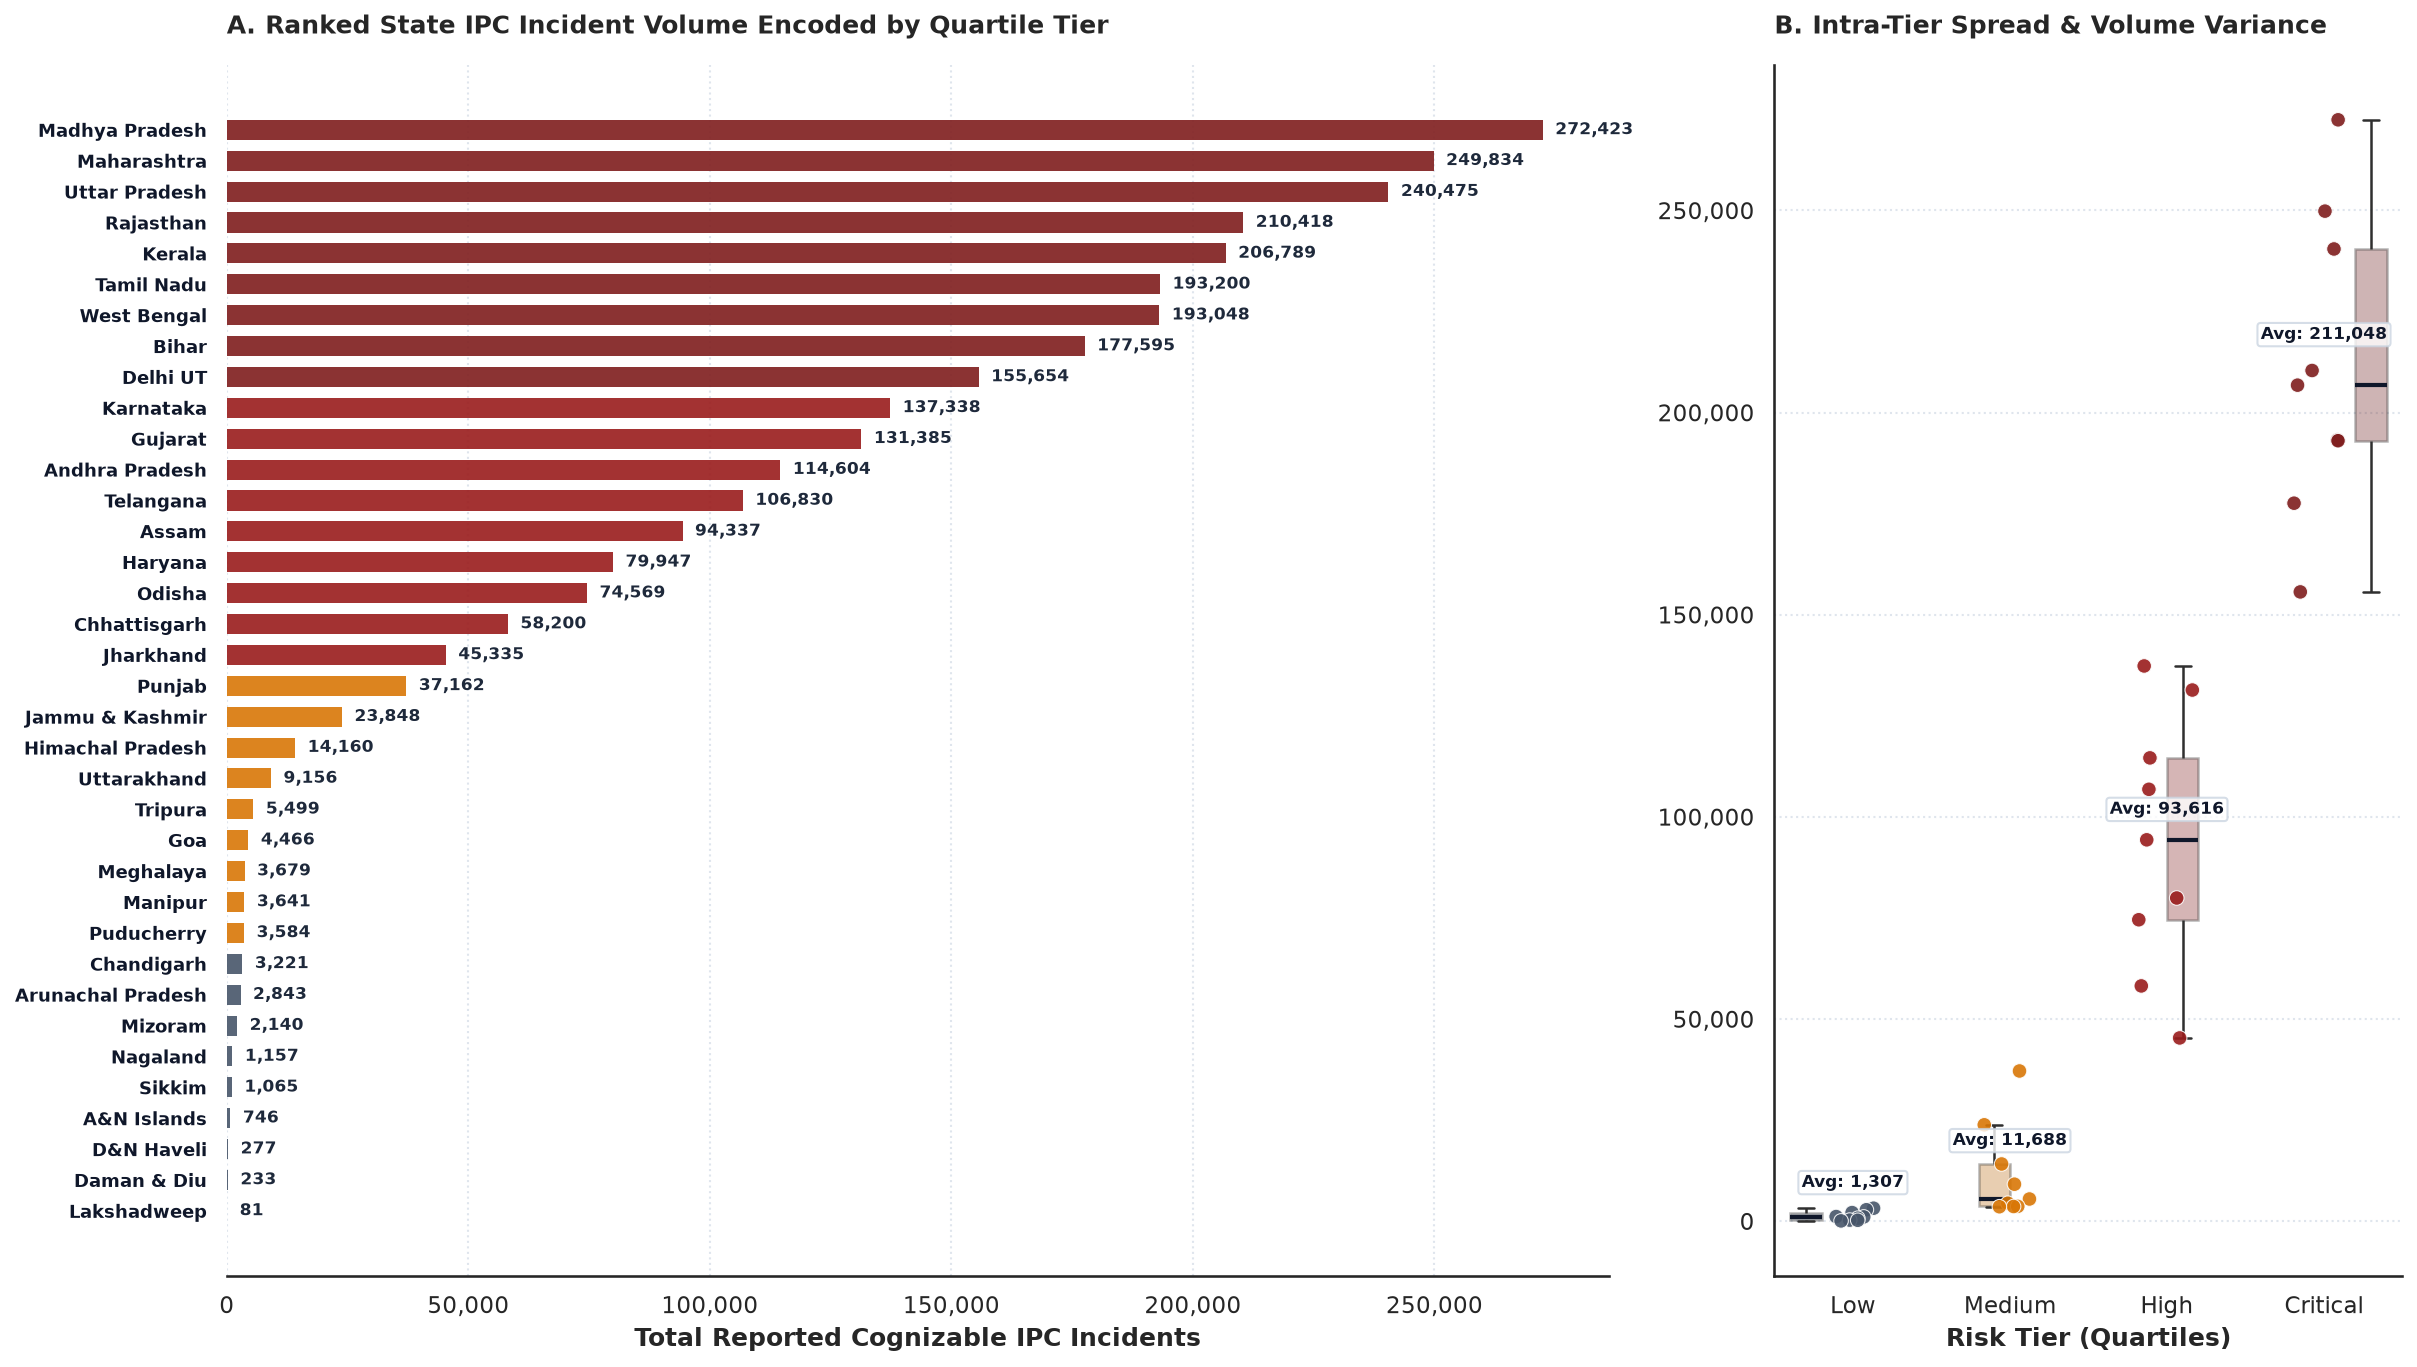

In [1112]:
df["Total Cognizable IPC crimes"] = pd.to_numeric(
    df["Total Cognizable IPC crimes"], errors="coerce"
).fillna(0)

if "crime_tier" not in df.columns:
    df["crime_tier"] = pd.qcut(
        df["Total Cognizable IPC crimes"],
        4,
        labels=["Low", "Medium", "High", "Critical"],
    )

df_sorted = df.sort_values(
    by="Total Cognizable IPC crimes", ascending=False
).reset_index(drop=True)

tier_colors = {
    "Critical": "#7f1d1d",
    "High": "#991b1b",
    "Medium": "#d97706",
    "Low": "#475569",
}

fig, (ax_main, ax_tier) = plt.subplots(
    1,
    2,
    figsize=(16, 9),
    dpi=150,
    layout="constrained",
    gridspec_kw={"width_ratios": [2.2, 1]},
)

y_pos = np.arange(len(df_sorted))
bar_colors = [tier_colors[tier] for tier in df_sorted["crime_tier"]]

ax_main.barh(
    y_pos,
    df_sorted["Total Cognizable IPC crimes"],
    align="center",
    color=bar_colors,
    height=0.65,
    edgecolor="none",
    alpha=0.9,
)

ax_main.set_yticks(y_pos)
ax_main.set_yticklabels(
    df_sorted["States/UTs"], fontsize=8.5, fontweight="bold", color="#0f172a"
)
ax_main.invert_yaxis()

ax_main.set_title(
    "A. Ranked State IPC Incident Volume Encoded by Quartile Tier",
    fontsize=12,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax_main.set_xlabel("Total Reported Cognizable IPC Incidents", fontweight="bold")
ax_main.xaxis.set_major_formatter("{x:,.0f}")
ax_main.xaxis.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")
ax_main.set_axisbelow(True)

for idx, row in df_sorted.iterrows():
    ax_main.annotate(
        f"{int(row['Total Cognizable IPC crimes']):,}",
        (row["Total Cognizable IPC crimes"], idx),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="bold",
        color="#1e293b",
    )

sns.boxplot(
    data=df_sorted,
    x="crime_tier",
    y="Total Cognizable IPC crimes",
    hue="crime_tier",
    legend=False,
    order=["Low", "Medium", "High", "Critical"],
    palette=tier_colors,
    ax=ax_tier,
    boxprops={"alpha": 0.35, "linewidth": 1.2},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
    medianprops={"linewidth": 2, "color": "#0f172a"},
    fliersize=0,
)

sns.stripplot(
    data=df_sorted,
    x="crime_tier",
    y="Total Cognizable IPC crimes",
    hue="crime_tier",
    legend=False,
    order=["Low", "Medium", "High", "Critical"],
    palette=tier_colors,
    size=7,
    jitter=0.2,
    alpha=0.9,
    linewidth=0.5,
    edgecolor="white",
    ax=ax_tier,
)

ax_tier.set_title(
    "B. Intra-Tier Spread & Volume Variance",
    fontsize=12,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax_tier.set_xlabel("Risk Tier (Quartiles)", fontweight="bold")
ax_tier.set_ylabel("")
ax_tier.yaxis.set_major_formatter("{x:,.0f}")
ax_tier.yaxis.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")
ax_tier.set_axisbelow(True)

tier_means = (
    df_sorted.groupby("crime_tier", observed=False)["Total Cognizable IPC crimes"]
    .mean()
    .to_dict()
)

for idx, tier_label in enumerate(["Low", "Medium", "High", "Critical"]):
    mean_val = tier_means[tier_label]
    ax_tier.annotate(
        f"Avg: {int(mean_val):,}",
        (idx, mean_val),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#0f172a",
        bbox={
            "boxstyle": "round,pad=0.2",
            "facecolor": "white",
            "edgecolor": "#cbd5e1",
            "alpha": 0.8,
        },
    )

sns.despine(ax=ax_main, top=True, right=True, left=True, bottom=False)
sns.despine(ax=ax_tier, top=True, right=True, left=False, bottom=False)

plt.show()

### 14. Acid Attack & Severe Assault Monitoring

In [1113]:
acid_cols = [col for col in df_state_totals.columns if "Acid" in col]
acid_attacks_df = df_state_totals[["States/UTs"] + acid_cols]
acid_attacks_df["total_acid_attacks"] = acid_attacks_df[acid_cols].sum(axis=1)
acid_attacks_df = (
    acid_attacks_df.sort_values(
        by="total_acid_attacks",
        ascending=False,
    )
    .reset_index()
    .drop(columns="index")
)
acid_attacks_df = acid_attacks_df[acid_attacks_df["total_acid_attacks"] > 1]

In [1114]:
acid_attacks_df.head()

,States/UTs,Acid attack,Attempt to Acid Attack,total_acid_attacks
0,Uttar Pradesh,42,13,55
1,West Bengal,40,4,44
2,Delhi UT,20,11,31
3,Punjab,15,2,17
4,Madhya Pradesh,14,2,16


In [1115]:
acid_attacks_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   States/UTs              19 non-null     str  
 1   Acid attack             19 non-null     int64
 2   Attempt to Acid Attack  19 non-null     int64
 3   total_acid_attacks      19 non-null     int64
dtypes: int64(3), str(1)
memory usage: 740.0 bytes


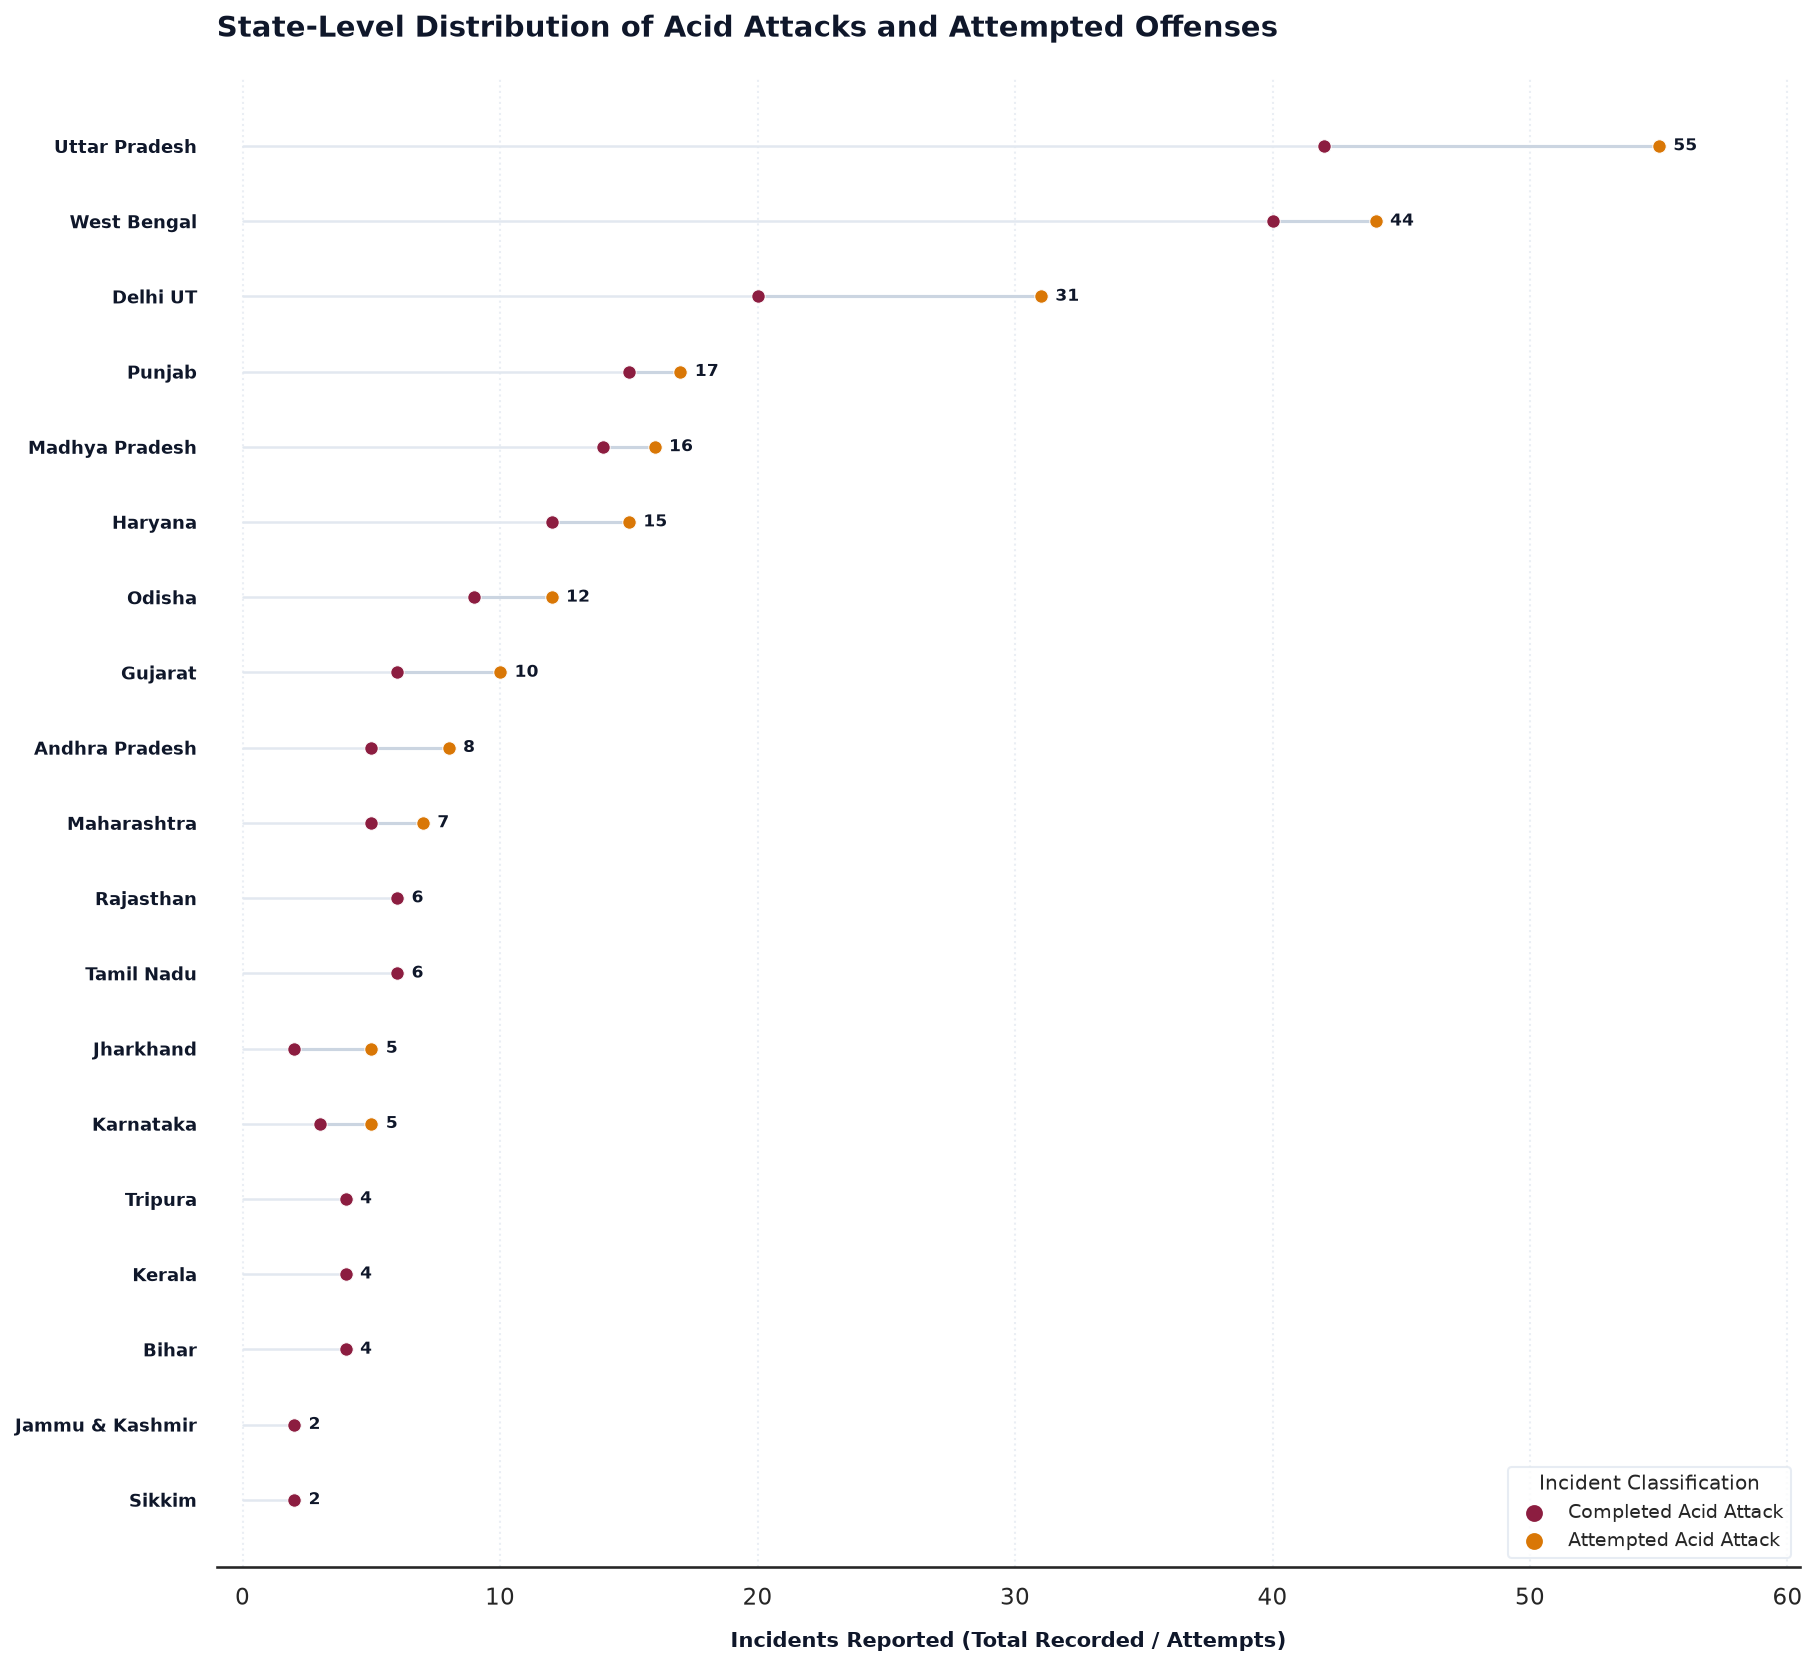

In [1116]:
df = acid_attacks_df.copy(deep=True)

acid_cols = [col for col in df.columns if "Acid" in col or "acid" in col]
attack_col = next(col for col in acid_cols if "Attempt" not in col)
attempt_col = next(col for col in acid_cols if "Attempt" in col)

df_plot = df.copy()
df_plot["total_acid_attacks"] = df_plot[attack_col] + df_plot[attempt_col]
df_plot = df_plot.sort_values(by="total_acid_attacks", ascending=True).reset_index(
    drop=True
)

color_attack = "#8c1d40"
color_attempt = "#d97706"
color_grid = "#e2e8f0"
color_text = "#0f172a"

fig, ax = plt.subplots(figsize=(12, 11), dpi=150, layout="constrained")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

y_positions = np.arange(len(df_plot))

for y, row in zip(y_positions, df_plot.to_dict("records")):
    val_attack = row[attack_col]
    val_attempt = row[attempt_col]
    val_total = row["total_acid_attacks"]

    if val_total > 0:
        ax.plot(
            [0, val_total],
            [y, y],
            color=color_grid,
            linewidth=1.2,
            zorder=1,
        )
        if val_attack > 0 and val_attempt > 0:
            ax.plot(
                [val_attack, val_total],
                [y, y],
                color="#cbd5e1",
                linewidth=1.5,
                zorder=2,
            )

        if val_attack > 0:
            ax.scatter(
                val_attack,
                y,
                color=color_attack,
                s=42,
                zorder=4,
                edgecolor="white",
                linewidth=0.5,
            )

        if val_attempt > 0:
            ax.scatter(
                val_total,
                y,
                color=color_attempt,
                s=42,
                zorder=4,
                edgecolor="white",
                linewidth=0.5,
            )

        ax.annotate(
            f"{val_total:,}",
            (val_total, y),
            xytext=(7, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            fontsize=8,
            fontweight="bold",
            color=color_text,
        )
    else:
        ax.scatter(
            0,
            y,
            color="#94a3b8",
            s=12,
            zorder=3,
            alpha=0.5,
        )

ax.set_yticks(y_positions)
ax.set_yticklabels(
    df_plot["States/UTs"],
    fontsize=8.5,
    fontweight="bold",
    color=color_text,
)

max_val = df_plot["total_acid_attacks"].max()
ax.set_xlim(-1, max_val * 1.1)
ax.xaxis.grid(True, linestyle=":", alpha=0.7, color=color_grid)
ax.set_axisbelow(True)
ax.set_xlabel(
    "Incidents Reported (Total Recorded / Attempts)",
    fontsize=10,
    fontweight="bold",
    color=color_text,
    labelpad=10,
)

sns.despine(ax=ax, top=True, right=True, left=True, bottom=False)

ax.scatter([], [], color=color_attack, s=50, label="Completed Acid Attack")
ax.scatter([], [], color=color_attempt, s=50, label="Attempted Acid Attack")
ax.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor=color_grid,
    fontsize=9,
    title="Incident Classification",
    title_fontsize=9.5,
)

ax.set_title(
    "State-Level Distribution of Acid Attacks and Attempted Offenses",
    fontsize=14,
    fontweight="bold",
    color=color_text,
    pad=20,
    loc="left",
)

plt.show()


### 15. Heatmap of State vs. Crime Types

In [1117]:
state_totals: pd.DataFrame = pd.DataFrame()

violent_crimes_against_person = [
    "Murder",
    "Attempt to commit Murder",
    "Culpable Homicide not amounting to Murder",
    "Attempt to commit Culpable Homicide",
    "Grievous Hurt",
    "Hurt",
    "Acid attack",
    "Attempt to Acid Attack",
    "Causing Death by Negligence",
    "Deaths due to negligent driving/act",
    "Deaths due to Other Causes",
    "Incidence of Rash Driving",
    "Unnatural Offence",
]

crimes_against_women = [
    "Rape",
    "Custodial Rape",
    "Custodial_Gang Rape",
    "Custodial_Other Rape",
    "Rape other than Custodial",
    "Rape_Gang Rape",
    "Rape_Others",
    "Attempt to commit Rape",
    "Assault on Women with intent to outrage her Modesty",
    "Sexual Harassment",
    "Assault or use of criminal force to women with intent to Disrobe",
    "Voyeurism",
    "Stalking",
    "Other Assault on Women",
    "Insult to the Modesty of Women",
    "At Office premises",
    "Other places related to work",
    "In Public Transport system",
    "Places other than 231, 232 & 233",
    "Cruelty by Husband or his Relatives",
    "Dowry Deaths",
    "Importation of Girls from Foreign Country",
]

kidnapping_and_trafficking = [
    "Kidnapping & Abduction_Total",
    "Kidnapping & Abduction",
    "Kidnapping & Abduction in order to Murder",
    "Kidnapping for Ransom",
    "Kidnapping & Abduction of Women to compel her for marriage",
    "Other Kidnapping",
    "HumanTrafficking",
]

property_crimes_and_robbery = [
    "Dacoity",
    "Dacoity with Murder",
    "Other Dacoity",
    "Making Preparation and Assembly for committing Dacoity",
    "Robbery",
    "Criminal Trespass/Burglary",
    "Criminal Trespass or Burglary",
    "House Trespass & House Breaking",
    "Theft",
    "Auto Theft",
    "Other Thefts",
    "Extortion",
    "Arson",
]

financial_and_white_collar_crimes = [
    "Criminal Breach of Trust",
    "Cheating",
    "Forgery",
    "Counterfeiting",
    "Counterfeit Offences related to Counterfeit Coin",
    "Counterfeiting Government Stamp",
    "Counterfeit currency & Bank notes",
    "Counterfeiting currency notes/Bank notes",
    "Using forged or counterfeiting currency/Bank notes",
    "Possession of forged or counterfeiting currency/Bank notes",
    "Making or Possessing materials for forged currency/Bank notes",
    "Making or Using documents resembling currency",
]

public_order_and_group_conflicts = [
    "Unlawful Assembly",
    "Riots",
    "Riots_Communal",
    "Riots_Industrial",
    "Riots_Political",
    "Riots_Caste Conflict",
    "Riots_SC/STs Vs Non-SCs/STs",
    "Riots_Other Caste Conflict",
    "Riots_Agrarian",
    "Riots_Students",
    "Riots_Sectarian",
    "Riots_Others",
]

crimes_against_state_and_society = [
    "Offences against State",
    "Sedition",
    "Other offences against State",
    "Offences promoting enmity between different groups",
    "Promoting enmity between different groups",
    "Imputation, assertions prejudicial to national integration",
    "Disclosure of Identity of Victims",
]

In [1118]:
category_mappings = {
    "crimes_against_state_and_society": crimes_against_state_and_society,
    "public_order_and_group_conflicts": public_order_and_group_conflicts,
    "financial_and_white_collar_crimes": financial_and_white_collar_crimes,
    "property_crimes_and_robbery": property_crimes_and_robbery,
    "kidnapping_and_trafficking": kidnapping_and_trafficking,
    "crimes_against_women": crimes_against_women,
    "violent_crimes_against_person": violent_crimes_against_person,
}

state_totals = pd.DataFrame(
    {
        "States/UTs": df_state_totals["States/UTs"],
        **{
            category: df_state_totals[cols].sum(axis=1)
            for category, cols in category_mappings.items()
        },
    }
)

In [1119]:
state_totals.head()

,States/UTs,crimes_against_state_and_society,public_order_and_group_conflicts,financial_and_white_collar_crimes,property_crimes_and_robbery,kidnapping_and_trafficking,crimes_against_women,violent_crimes_against_person
20,Andhra Pradesh,44,2104,6705,41982,2134,24017,33374
40,Arunachal Pradesh,0,72,153,1689,292,550,904
69,Assam,112,6114,5192,38943,9714,22182,25190
116,Bihar,40,27498,8009,59345,13184,11197,56076
145,Chhattisgarh,20,1837,1222,19588,4071,9823,24970


In [1120]:
state_totals.info()

<class 'pandas.DataFrame'>
Index: 36 entries, 20 to 837
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   States/UTs                         36 non-null     str  
 1   crimes_against_state_and_society   36 non-null     int64
 2   public_order_and_group_conflicts   36 non-null     int64
 3   financial_and_white_collar_crimes  36 non-null     int64
 4   property_crimes_and_robbery        36 non-null     int64
 5   kidnapping_and_trafficking         36 non-null     int64
 6   crimes_against_women               36 non-null     int64
 7   violent_crimes_against_person      36 non-null     int64
dtypes: int64(7), str(1)
memory usage: 3.6 KB


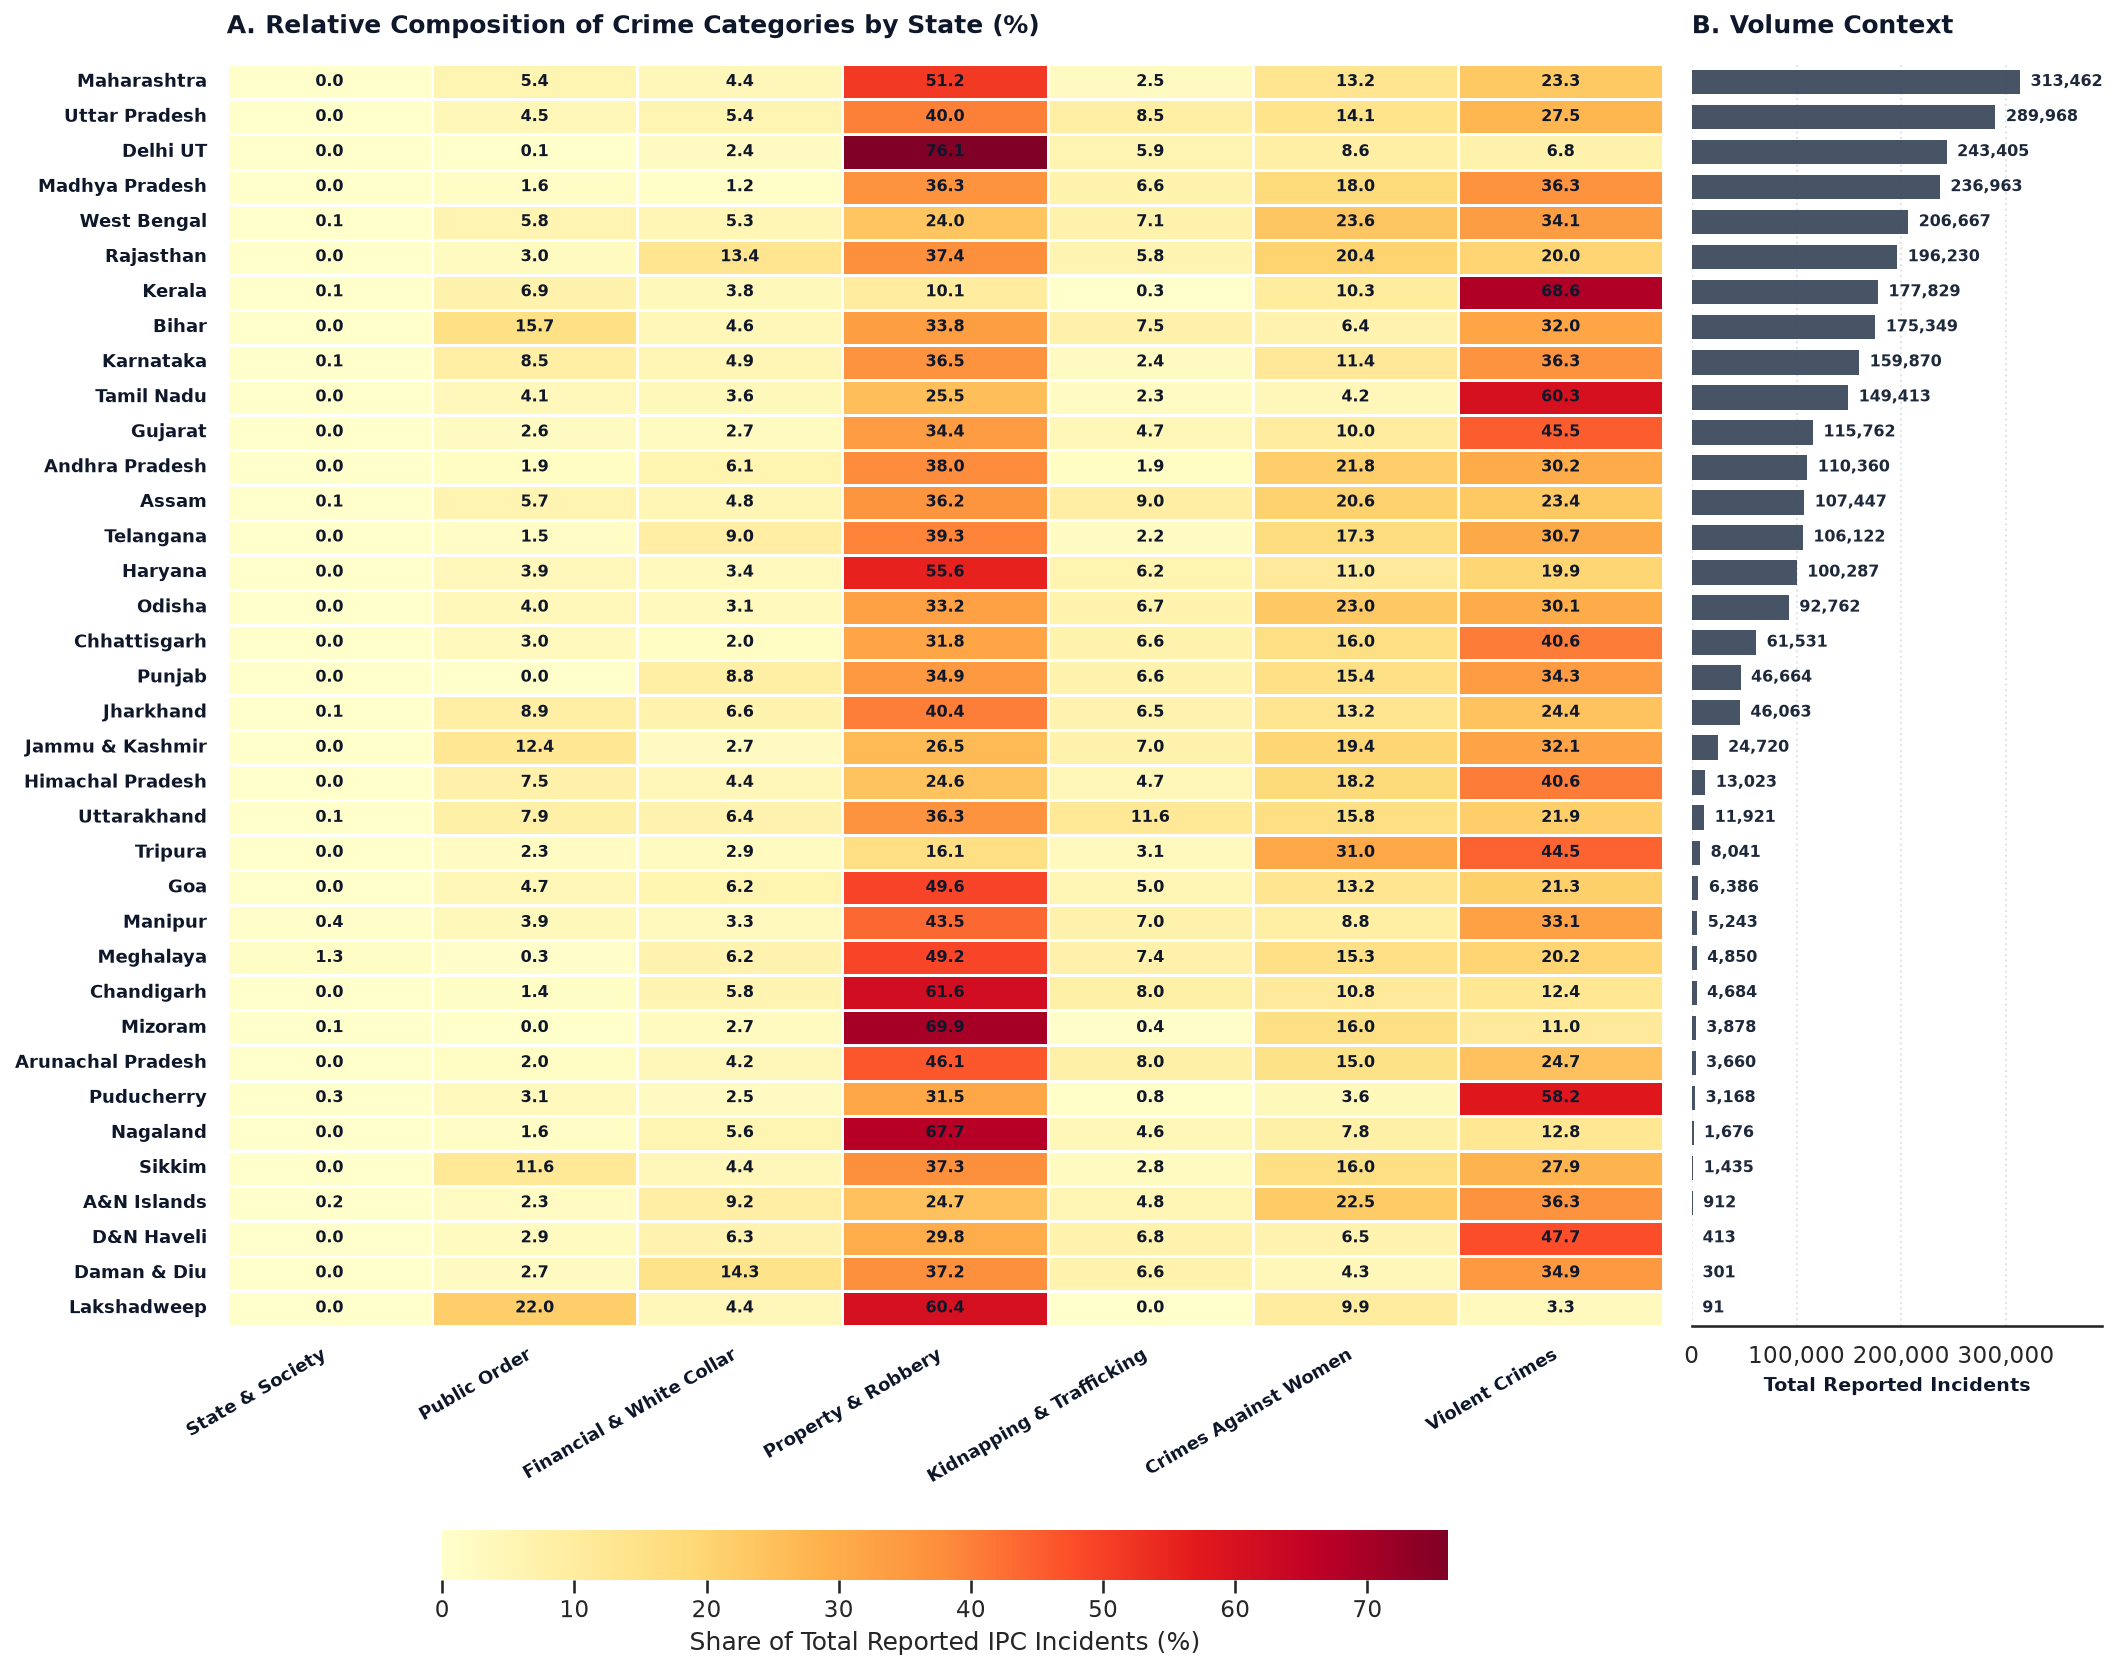

In [1121]:
crime_categories = [
    "crimes_against_state_and_society",
    "public_order_and_group_conflicts",
    "financial_and_white_collar_crimes",
    "property_crimes_and_robbery",
    "kidnapping_and_trafficking",
    "crimes_against_women",
    "violent_crimes_against_person",
]

column_clean_names = {
    "crimes_against_state_and_society": "State & Society",
    "public_order_and_group_conflicts": "Public Order",
    "financial_and_white_collar_crimes": "Financial & White Collar",
    "property_crimes_and_robbery": "Property & Robbery",
    "kidnapping_and_trafficking": "Kidnapping & Trafficking",
    "crimes_against_women": "Crimes Against Women",
    "violent_crimes_against_person": "Violent Crimes",
}

df_analysis = state_totals.copy(deep=True)
df_analysis["total_incidents"] = df_analysis[crime_categories].sum(axis=1)
df_analysis = df_analysis.sort_values(
    by="total_incidents", ascending=False
).reset_index(drop=True)

df_percent = (
    df_analysis[crime_categories].div(df_analysis["total_incidents"], axis=0) * 100
)
df_percent.index = df_analysis["States/UTs"]
df_percent = df_percent.rename(columns=column_clean_names)

fig, (ax_heatmap, ax_bar) = plt.subplots(
    1,
    2,
    figsize=(14, 11),
    dpi=150,
    layout="constrained",
    gridspec_kw={"width_ratios": [3.5, 1]},
)

fig.patch.set_facecolor("white")
ax_heatmap.set_facecolor("white")
ax_bar.set_facecolor("white")

cmap = sns.color_palette("YlOrRd", as_cmap=True)

sns.heatmap(
    df_percent,
    ax=ax_heatmap,
    cmap=cmap,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7.5, "weight": "bold", "color": "#0f172a"},
    cbar_kws={
        "label": "Share of Total Reported IPC Incidents (%)",
        "orientation": "horizontal",
        "pad": 0.03,
        "shrink": 0.7,
    },
    linewidths=0.5,
    linecolor="#ffffff",
)

ax_heatmap.set_title(
    "A. Relative Composition of Crime Categories by State (%)",
    fontsize=12,
    fontweight="bold",
    color="#0f172a",
    pad=15,
    loc="left",
)
ax_heatmap.set_xlabel("")
ax_heatmap.set_ylabel("")
ax_heatmap.set_xticklabels(
    ax_heatmap.get_xticklabels(),
    rotation=30,
    ha="right",
    fontsize=8.5,
    fontweight="bold",
    color="#0f172a",
)
ax_heatmap.set_yticklabels(
    ax_heatmap.get_yticklabels(),
    rotation=0,
    fontsize=8.5,
    fontweight="bold",
    color="#0f172a",
)

y_positions = np.arange(len(df_analysis)) + 0.5
totals = df_analysis["total_incidents"]

ax_bar.barh(
    y_positions,
    totals,
    height=0.7,
    color="#334155",
    edgecolor="none",
    alpha=0.9,
)

ax_bar.set_title(
    "B. Volume Context",
    fontsize=12,
    fontweight="bold",
    color="#0f172a",
    pad=15,
    loc="left",
)
ax_bar.set_xlabel(
    "Total Reported Incidents",
    fontsize=9,
    fontweight="bold",
    color="#0f172a",
)
ax_bar.set_ylim(len(df_analysis), 0)
ax_bar.set_yticks(y_positions)
ax_bar.set_yticklabels([])
ax_bar.xaxis.set_major_formatter("{x:,.0f}")
ax_bar.xaxis.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")
ax_bar.set_axisbelow(True)

for y, total in zip(y_positions, totals):
    ax_bar.annotate(
        f"{total:,}",
        (total, y),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=7.5,
        fontweight="bold",
        color="#1e293b",
    )

max_total = totals.max()
ax_bar.set_xlim(0, max_total * 1.25)

sns.despine(ax=ax_heatmap, top=True, right=True, left=True, bottom=True)
sns.despine(ax=ax_bar, top=True, right=True, left=True, bottom=False)

plt.show()

### 16. Outlier Detection Boxplot Analysis

In [1122]:
df_state_totals.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
20,Andhra Pradesh,Total,2014,1175,1540,52,1,961,0,0,...,21,21,0,276,0,14653,2,1,44187,114604
40,Arunachal Pradesh,Total,2014,86,48,4,0,83,4,0,...,0,0,0,121,0,102,0,0,720,2843
69,Assam,Total,2014,1451,1142,57,14,1980,0,0,...,0,0,0,1226,0,3202,68,0,29212,94337
116,Bihar,Total,2014,3403,4379,201,463,1127,0,0,...,0,0,0,972,0,3485,44,5,75799,177595
145,Chhattisgarh,Total,2014,998,716,29,0,1436,0,0,...,3,3,0,74,0,7759,43,22,21897,58200


In [1123]:
df_for_anomaly_check: pd.DataFrame = df_state_totals.select_dtypes(include=np.number)

In [1124]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=777)
model.fit(df_for_anomaly_check)

scores = model.decision_function(df_for_anomaly_check)
labels = model.predict(df_for_anomaly_check)  # -1 = anomaly, 1 = normal

df_checked = df_state_totals.copy(deep=True)
df_checked["scores"] = scores
df_checked["labels"] = labels

In [1125]:
df_checked.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes,scores,labels
20,Andhra Pradesh,Total,2014,1175,1540,52,1,961,0,0,...,0,276,0,14653,2,1,44187,114604,0.167748,1
40,Arunachal Pradesh,Total,2014,86,48,4,0,83,4,0,...,0,121,0,102,0,0,720,2843,0.285176,1
69,Assam,Total,2014,1451,1142,57,14,1980,0,0,...,0,1226,0,3202,68,0,29212,94337,0.134142,1
116,Bihar,Total,2014,3403,4379,201,463,1127,0,0,...,0,972,0,3485,44,5,75799,177595,0.069817,1
145,Chhattisgarh,Total,2014,998,716,29,0,1436,0,0,...,0,74,0,7759,43,22,21897,58200,0.231775,1


In [1126]:
df_checked["labels"].value_counts()

labels
 1    34
-1     2
Name: count, dtype: int64

In [1127]:
df_checked[df_checked["labels"] == -1]

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes,scores,labels
452,Maharashtra,Total,2014,2670,2613,171,11,3438,0,0,...,2,780,0,26060,108,102,62286,249834,-0.006758,-1
756,Uttar Pradesh,Total,2014,5150,5223,1412,506,3467,189,5,...,1,609,0,16199,4,137,66277,240475,-0.009412,-1


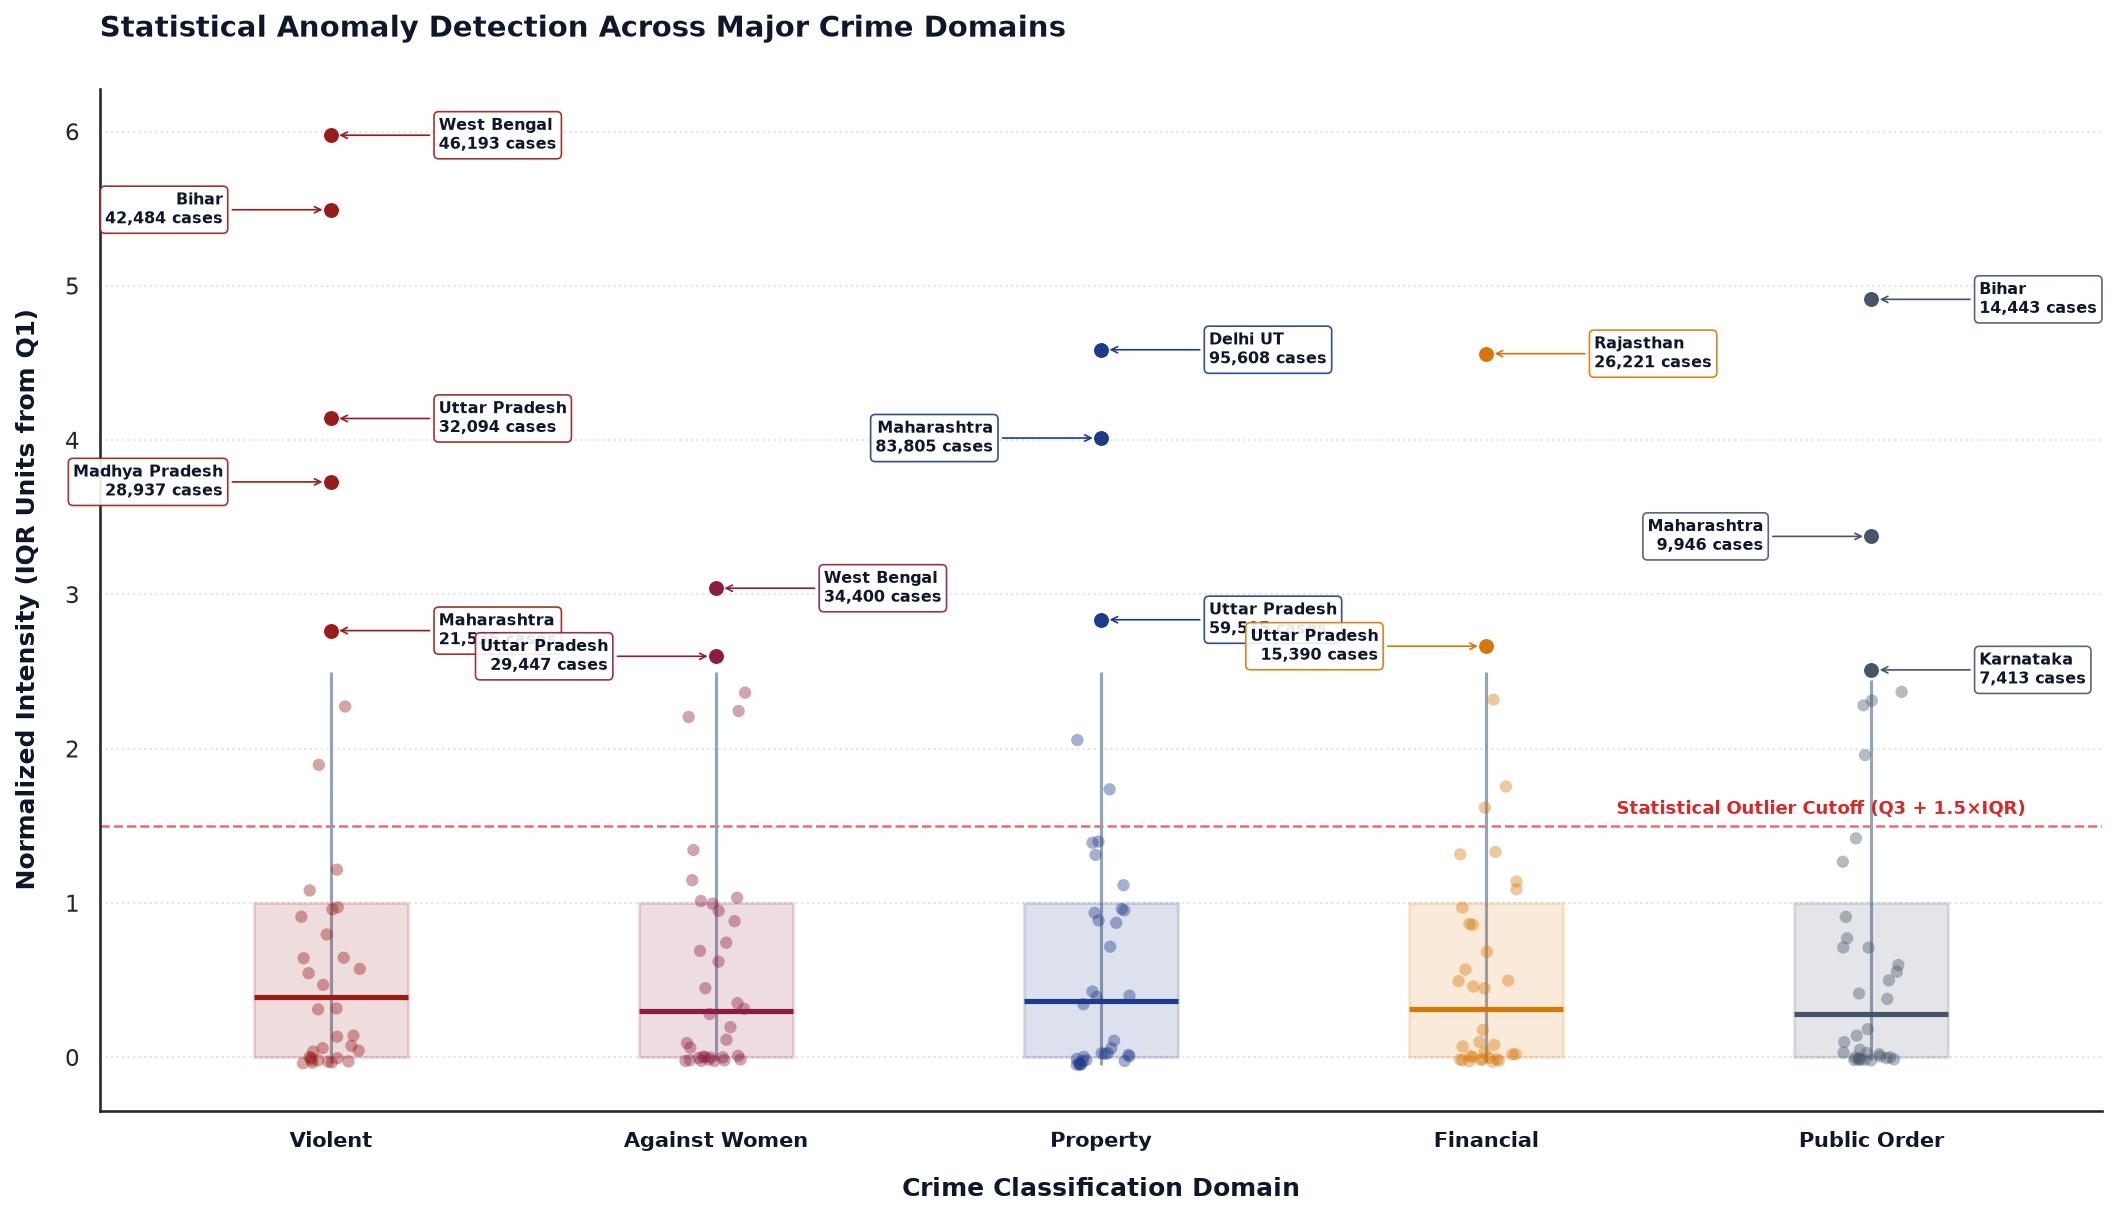

In [1128]:
df = df_state_totals.copy(deep=True)

crime_categories = {
    "Violent": [
        "Murder",
        "Attempt to commit Murder",
        "Grievous Hurt",
        "Hurt",
        "Acid attack",
    ],
    "Against Women": [
        "Rape",
        "Assault on Women with intent to outrage her Modesty",
        "Sexual Harassment",
        "Cruelty by Husband or his Relatives",
        "Dowry Deaths",
    ],
    "Property": [
        "Auto Theft",
        "Other Thefts",
        "Criminal Trespass/Burglary",
        "Robbery",
        "Dacoity",
    ],
    "Financial": [
        "Cheating",
        "Forgery",
        "Criminal Breach of Trust",
        "Counterfeiting",
    ],
    "Public Order": [
        "Riots",
        "Unlawful Assembly",
        "Arson",
    ],
}

category_totals = pd.DataFrame({"States/UTs": df["States/UTs"]})
for cat_name, cols in crime_categories.items():
    valid_cols = [c for c in cols if c in df.columns]
    category_totals[cat_name] = df[valid_cols].sum(axis=1)

scaled_df = category_totals.copy()
for cat_name in crime_categories:
    vals = scaled_df[cat_name]
    q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q75 - q25
    scaled_df[cat_name] = (vals - q25) / (iqr if iqr > 0 else 1.0)

categories_list = list(crime_categories.keys())

category_colors = {
    "Violent": "#991b1b",
    "Against Women": "#8c1d40",
    "Property": "#1e3a8a",
    "Financial": "#d97706",
    "Public Order": "#475569",
}

fig, ax = plt.subplots(figsize=(14, 8), dpi=150, layout="constrained")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for cat_idx, cat_name in enumerate(categories_list):
    color = category_colors[cat_name]
    cat_data = scaled_df[["States/UTs", cat_name]].copy()
    vals = cat_data[cat_name]

    q25 = vals.quantile(0.25)
    q50 = vals.median()
    q75 = vals.quantile(0.75)
    iqr = q75 - q25
    upper_whisker = min(vals.max(), q75 + 1.5 * iqr)
    lower_whisker = max(vals.min(), q25 - 1.5 * iqr)
    upper_threshold = q75 + 1.5 * iqr

    ax.vlines(
        x=cat_idx,
        ymin=lower_whisker,
        ymax=upper_whisker,
        colors="#94a3b8",
        linewidth=1.5,
        zorder=1,
    )

    rect = plt.Rectangle(
        (cat_idx - 0.2, q25),
        0.4,
        q75 - q25,
        facecolor=color,
        alpha=0.15,
        edgecolor=color,
        linewidth=1.5,
        zorder=2,
    )
    ax.add_patch(rect)

    ax.hlines(
        y=q50,
        xmin=cat_idx - 0.2,
        xmax=cat_idx + 0.2,
        colors=color,
        linewidth=2.5,
        zorder=3,
    )

    inliers = cat_data[vals <= upper_threshold]
    outliers = cat_data[vals > upper_threshold].sort_values(
        by=cat_name, ascending=False
    )

    np.random.seed(42 + cat_idx)
    jitters = np.random.uniform(-0.08, 0.08, size=len(inliers))

    ax.scatter(
        cat_idx + jitters,
        inliers[cat_name],
        color=color,
        alpha=0.4,
        s=35,
        edgecolor="none",
        zorder=4,
    )

    for out_idx, (_, row) in enumerate(outliers.iterrows()):
        state = row["States/UTs"]
        scaled_val = row[cat_name]
        raw_val = category_totals.loc[
            category_totals["States/UTs"] == state, cat_name
        ].values[0]

        ax.scatter(
            cat_idx,
            scaled_val,
            color=color,
            s=70,
            edgecolor="white",
            linewidth=1.2,
            zorder=5,
        )

        x_offset = 0.28 if (out_idx % 2 == 0) else -0.28
        ha_align = "left" if x_offset > 0 else "right"

        ax.annotate(
            f"{state}\n{raw_val:,} cases",
            (cat_idx, scaled_val),
            xytext=(cat_idx + x_offset, scaled_val),
            ha=ha_align,
            va="center",
            fontsize=7.5,
            fontweight="bold",
            color="#0f172a",
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": color,
                "alpha": 0.9,
                "linewidth": 0.8,
            },
            arrowprops={
                "arrowstyle": "->",
                "color": color,
                "linewidth": 0.8,
                "shrinkB": 4,
            },
            zorder=6,
        )

ax.axhline(
    1.5,
    color="#ef4444",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    zorder=0,
)

ax.text(
    4.4,
    1.55,
    "Statistical Outlier Cutoff (Q3 + 1.5×IQR)",
    color="#dc2626",
    fontsize=8.5,
    fontweight="bold",
    ha="right",
    va="bottom",
)

ax.set_title(
    "Statistical Anomaly Detection Across Major Crime Domains",
    fontsize=14,
    fontweight="bold",
    color="#0f172a",
    pad=25,
    loc="left",
)

ax.set_xlabel(
    "Crime Classification Domain", fontweight="bold", color="#0f172a", labelpad=12
)
ax.set_ylabel(
    "Normalized Intensity (IQR Units from Q1)",
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

ax.set_xticks(np.arange(len(categories_list)))
ax.set_xticklabels(
    categories_list,
    fontsize=10,
    fontweight="bold",
    color="#0f172a",
)

ax.set_xlim(-0.6, len(categories_list) - 0.4)
ax.yaxis.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")
ax.set_axisbelow(True)

sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

plt.show()

### 17. Pareto Analysis for National Crime Volume

In [1129]:
df_total_ipc_crimes = (
    df_state_totals[["States/UTs", "Total Cognizable IPC crimes"]]
    .sort_values(
        by="Total Cognizable IPC crimes",
        ascending=True,
    )
    .reset_index(drop=True)
)
df_total_ipc_crimes["cum_sum_pct"] = (
    df_total_ipc_crimes["Total Cognizable IPC crimes"].cumsum()
    / df_total_ipc_crimes["Total Cognizable IPC crimes"].sum()
) * 100

In [1130]:
df_total_ipc_crimes.tail()

,States/UTs,Total Cognizable IPC crimes,cum_sum_pct
31,Kerala,206789,65.961149
32,Rajasthan,210418,73.321152
33,Uttar Pradesh,240475,81.732489
34,Maharashtra,249834,90.471185
35,Madhya Pradesh,272423,100.000000


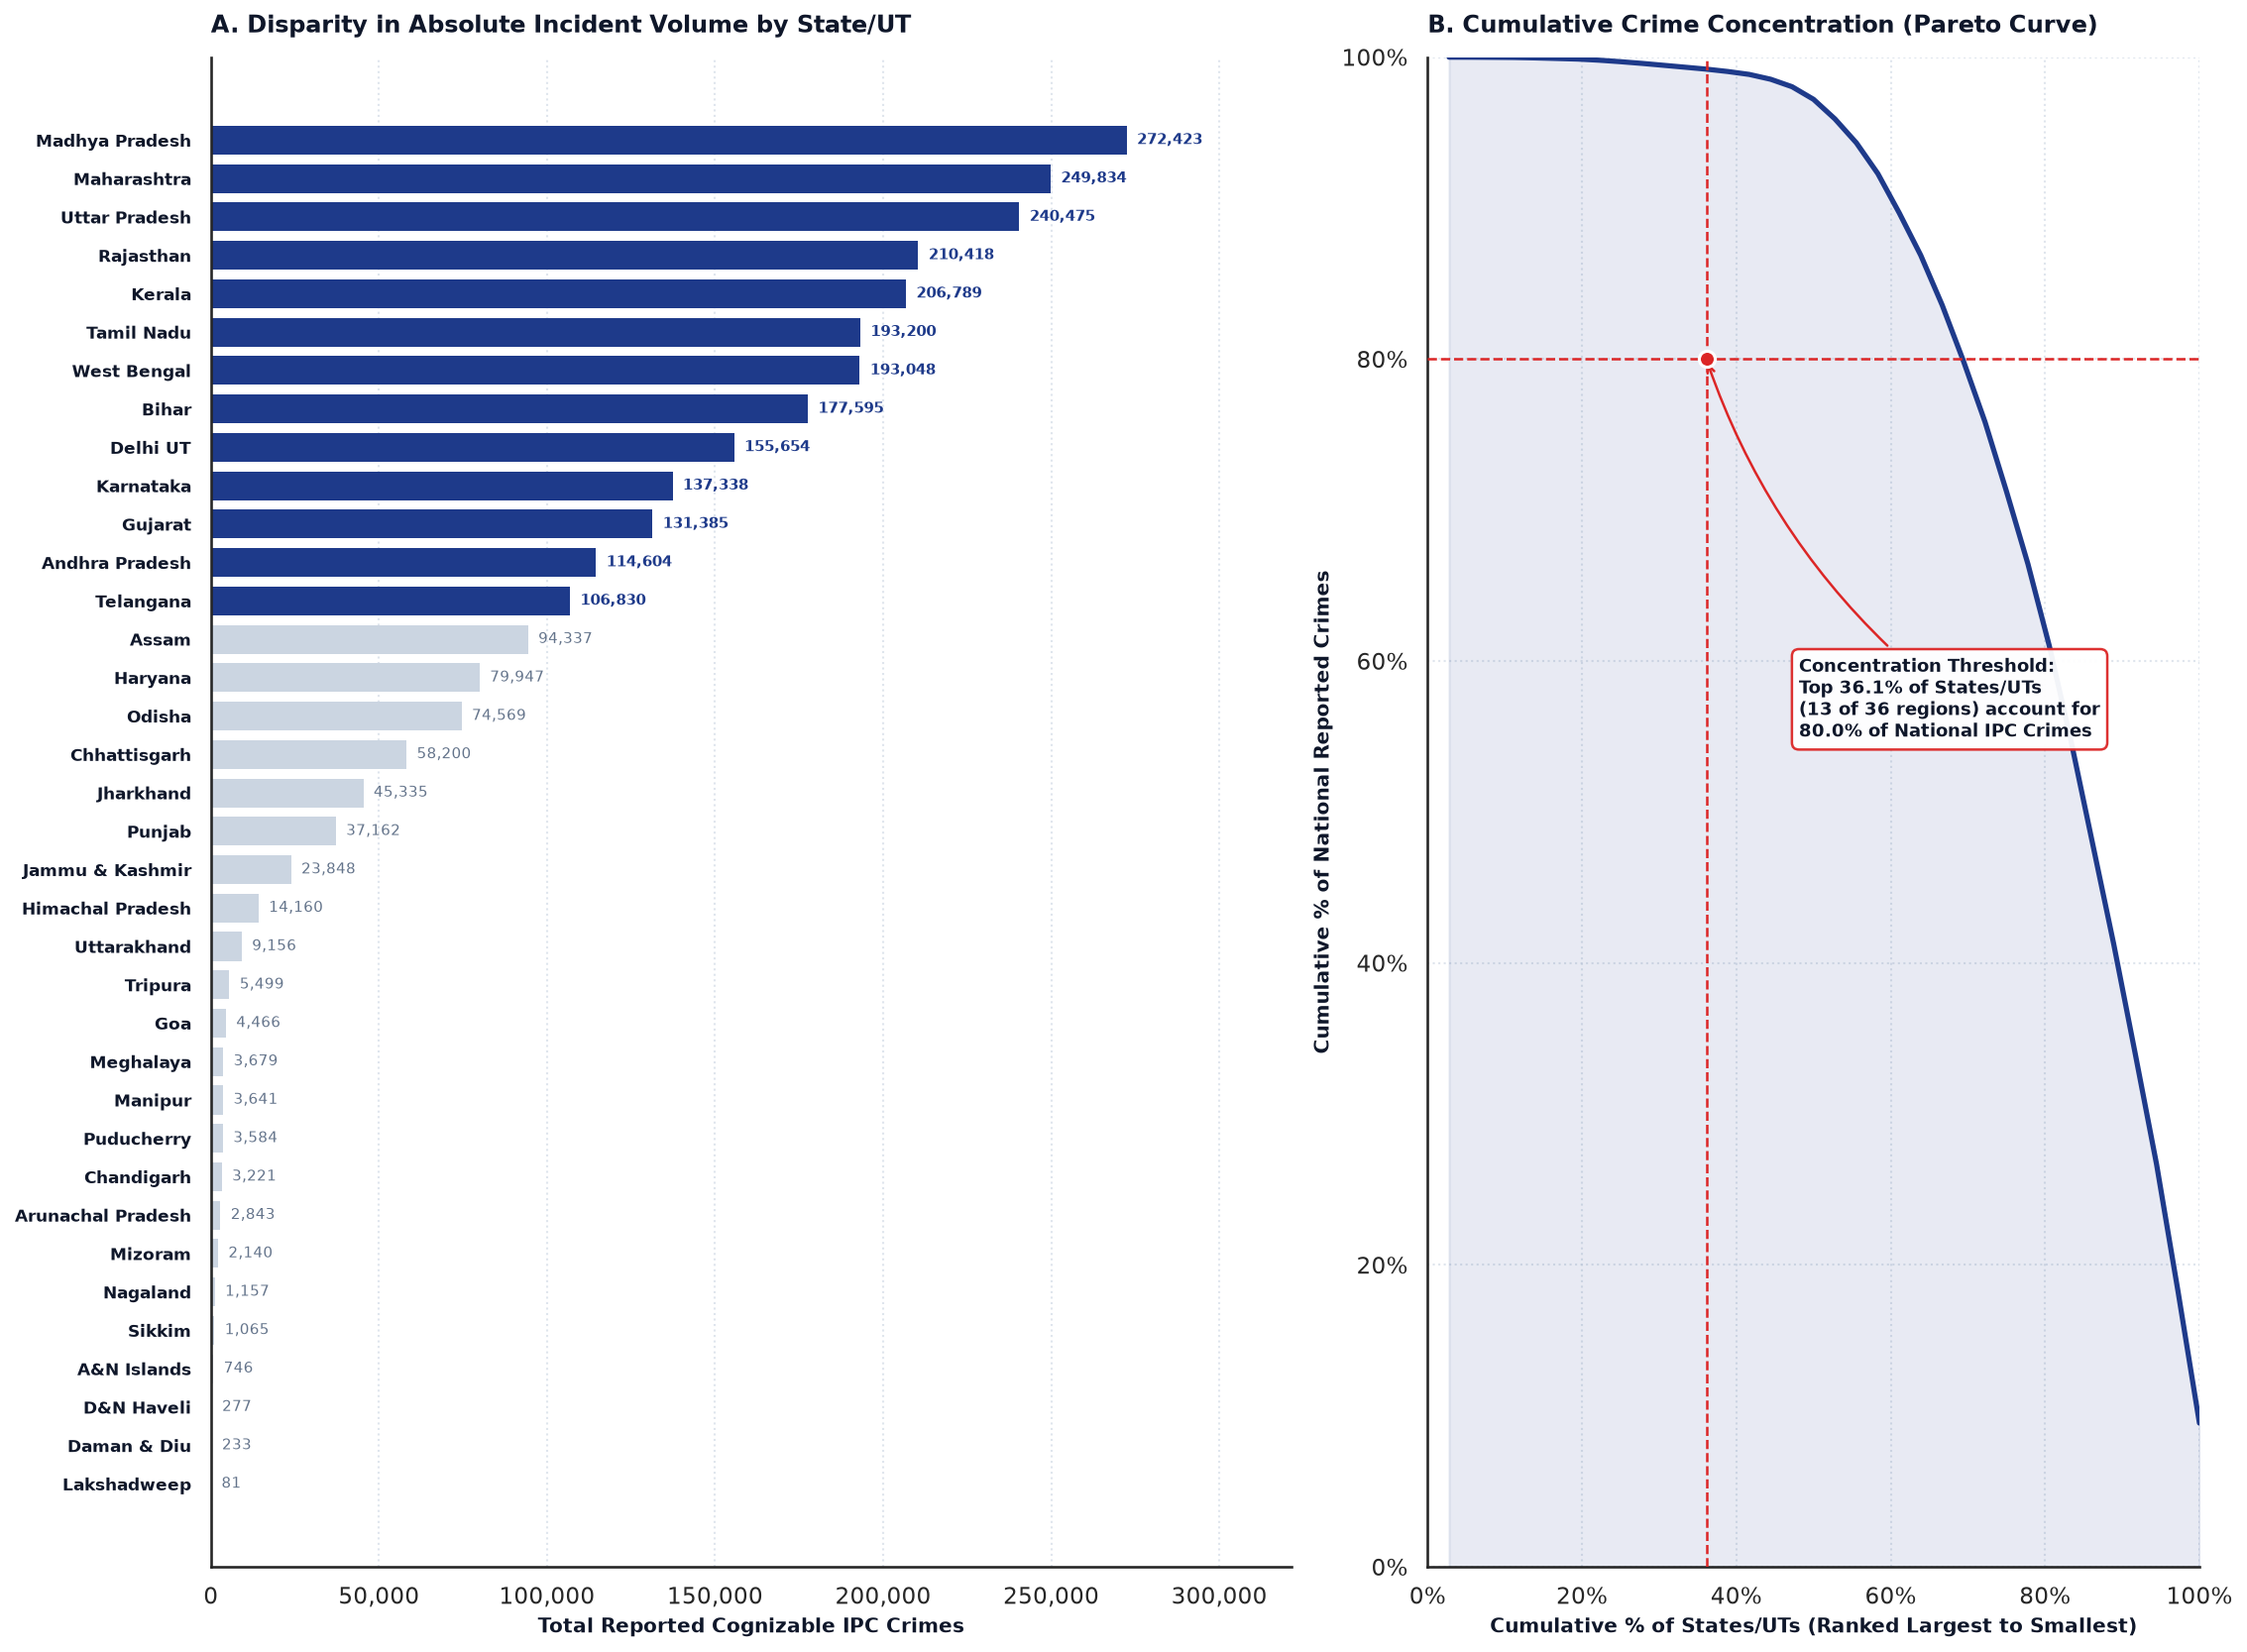

In [1131]:
plot_df = df_total_ipc_crimes.copy()
if "cum_sum_pct" not in plot_df.columns:
    total_val = plot_df["Total Cognizable IPC crimes"].sum()
    plot_df = plot_df.sort_values(
        by="Total Cognizable IPC crimes", ascending=True
    ).reset_index(drop=True)
    plot_df["cum_sum_pct"] = (
        plot_df["Total Cognizable IPC crimes"].cumsum() / total_val
    ) * 100

total_units = len(plot_df)
eighty_pct_units = (plot_df["cum_sum_pct"] >= 20.0).sum()
pct_units_for_80_crime = (eighty_pct_units / total_units) * 100

plot_df["is_top_80"] = plot_df["cum_sum_pct"] >= 20.0

fig, (ax_bar, ax_pareto) = plt.subplots(
    1,
    2,
    figsize=(15, 11),
    dpi=150,
    layout="constrained",
    gridspec_kw={"width_ratios": [1.4, 1]},
)
fig.patch.set_facecolor("white")
ax_bar.set_facecolor("white")
ax_pareto.set_facecolor("white")

colors = ["#1e3a8a" if is_top else "#cbd5e1" for is_top in plot_df["is_top_80"]]

y_pos = np.arange(total_units)
ax_bar.barh(
    y_pos,
    plot_df["Total Cognizable IPC crimes"],
    color=colors,
    height=0.75,
    edgecolor="none",
)

ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(
    plot_df["States/UTs"],
    fontsize=8,
    fontweight="bold",
    color="#0f172a",
)
ax_bar.xaxis.set_major_formatter("{x:,.0f}")
ax_bar.set_xlabel(
    "Total Reported Cognizable IPC Crimes",
    fontweight="bold",
    color="#0f172a",
    fontsize=9.5,
)
ax_bar.set_title(
    "A. Disparity in Absolute Incident Volume by State/UT",
    fontsize=11.5,
    fontweight="bold",
    color="#0f172a",
    pad=12,
    loc="left",
)
ax_bar.xaxis.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")
ax_bar.set_axisbelow(True)

max_val = plot_df["Total Cognizable IPC crimes"].max()
ax_bar.set_xlim(0, max_val * 1.18)

for y, val, is_top in zip(
    y_pos, plot_df["Total Cognizable IPC crimes"], plot_df["is_top_80"]
):
    text_color = "#1e3a8a" if is_top else "#64748b"
    font_weight = "bold" if is_top else "normal"
    ax_bar.annotate(
        f"{val:,}",
        (val, y),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=7,
        fontweight=font_weight,
        color=text_color,
    )

rank_pct = np.linspace(100 / total_units, 100, total_units)
cum_crime_from_top = 100.0 - np.insert(plot_df["cum_sum_pct"].values[:-1], 0, 0.0)

ax_pareto.plot(
    rank_pct,
    cum_crime_from_top,
    color="#1e3a8a",
    linewidth=2.5,
    zorder=3,
)
ax_pareto.fill_between(
    rank_pct,
    cum_crime_from_top,
    color="#1e3a8a",
    alpha=0.1,
    zorder=2,
)

ax_pareto.axhline(
    80,
    color="#dc2626",
    linestyle="--",
    linewidth=1.2,
    zorder=4,
)
ax_pareto.axvline(
    pct_units_for_80_crime,
    color="#dc2626",
    linestyle="--",
    linewidth=1.2,
    zorder=4,
)

ax_pareto.scatter(
    [pct_units_for_80_crime],
    [80],
    color="#dc2626",
    s=60,
    zorder=5,
    edgecolor="white",
    linewidth=1.5,
)

ax_pareto.annotate(
    f"Concentration Threshold:\nTop {pct_units_for_80_crime:.1f}% of States/UTs\n({eighty_pct_units} of {total_units} regions) account for\n80.0% of National IPC Crimes",
    xy=(pct_units_for_80_crime, 80),
    xytext=(pct_units_for_80_crime + 12, 55),
    fontsize=8.5,
    fontweight="bold",
    color="#0f172a",
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "edgecolor": "#dc2626",
        "alpha": 0.95,
        "linewidth": 1.2,
    },
    arrowprops={
        "arrowstyle": "->",
        "color": "#dc2626",
        "linewidth": 1.2,
        "connectionstyle": "arc3,rad=-0.15",
    },
)

ax_pareto.set_title(
    "B. Cumulative Crime Concentration (Pareto Curve)",
    fontsize=11.5,
    fontweight="bold",
    color="#0f172a",
    pad=12,
    loc="left",
)
ax_pareto.set_xlabel(
    "Cumulative % of States/UTs (Ranked Largest to Smallest)",
    fontweight="bold",
    color="#0f172a",
    fontsize=9.5,
)
ax_pareto.set_ylabel(
    "Cumulative % of National Reported Crimes",
    fontweight="bold",
    color="#0f172a",
    fontsize=9.5,
)

ax_pareto.set_xlim(0, 100)
ax_pareto.set_ylim(0, 100)
ax_pareto.xaxis.set_major_formatter("{x:.0f}%")
ax_pareto.yaxis.set_major_formatter("{x:.0f}%")

ax_pareto.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")
ax_pareto.set_axisbelow(True)

sns.despine(ax=ax_bar, top=True, right=True, left=False, bottom=False)
sns.despine(ax=ax_pareto, top=True, right=True, left=False, bottom=False)

plt.show()
